#### 1. 箱型图
读取 wanderjoin_comparison_dataset_three2.csv 中 两个Uniform 和 Importance 的估计值T_hat 以及results_summary_run_1.csv 中method = FOIS_nrs 和FOIS_rs 和POSS方法的T_hat ，根据T_true 绘制 相对误差（有符号相对误差 (Est - True) / True）箱型图，要美观直观（可以自定义调整各种参数）。
 wanderjoin_comparison_dataset_three2.csv：
 query_basename,method,T_true,T_hat,Qerror,AbsRelativeError,SuccessRate,n_post,trials
query_cycle_4_0.graph,Uniform,491800.0,622708.5031185031,0.2661823975569401,0.2661823975569401,0.158004158004158,416,481
query_cycle_4_0.graph,Importance,491800.0,511726.31789487816,0.04051711650036226,0.04051711650036226,0.18487394957983194,416,476

results_summary_run_1.csv ：
query_index,query_basename,gt_match_col,T_true,method,T_hat,Qerror,n_post,n_comment
0,query_cycle_4_0.graph,u1,491800.0,UN,267508.4382259616,0.4560625493575405,416,0
0,query_cycle_4_0.graph,u1,491800.0,PO,484236.74386347167,0.015378723335763182,416,0

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

# --- 用户配置 ---
PLOT_POINTS = False      # True: 画散点; False: 只画箱型图 11
Y_LIMITS = (-1, 1)      # Y轴显示范围，None 表示自动

# --- 1. 定义文件路径 ---
wj_csv_path = "/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_dataset_three2.csv"
baseline_csv_path = "/home/wangshuo/resource/datasets/parler_data/dataset_three/results/result_summarys/ML1_proxy4b_probability/results_summary_run_1.csv"

# --- 2. 加载 WanderJoin 数据 ---
if not os.path.exists(wj_csv_path):
    raise FileNotFoundError(f"[Error] File not found: {wj_csv_path}")
df_wj = pd.read_csv(wj_csv_path)

# 只保留 Uniform 和 Importance，重命名为 WJP / WJU
df_wj_target = df_wj[df_wj['method'].isin(['Uniform', 'Importance'])].copy()
rename_map = {'Uniform': 'WJP', 'Importance': 'WJU'}
df_wj_target['method'] = df_wj_target['method'].map(rename_map).fillna(df_wj_target['method'])
df_wj_target['RelativeError'] = (df_wj_target['T_hat'] - df_wj_target['T_true']) / df_wj_target['T_true']
print(f"[WanderJoin] Loaded {len(df_wj_target)} rows. Methods: {df_wj_target['method'].unique()}")

# --- 3. 加载 Baseline (FOIS/POSS) 数据 ---
if not os.path.exists(baseline_csv_path):
    print(f"[Warning] Baseline file not found: {baseline_csv_path}")
    df_base_target = pd.DataFrame(columns=['method', 'RelativeError'])
else:
    df_base = pd.read_csv(baseline_csv_path)
    target_methods = ['FOIS_nrs', 'FOIS_rs', 'POSS']
    df_base_target = df_base[df_base['method'].isin(target_methods)].copy()
    df_base_target['RelativeError'] = (df_base_target['T_hat'] - df_base_target['T_true']) / df_base_target['T_true']
    print(f"[Baseline] Loaded {len(df_base_target)} rows. Methods: {df_base_target['method'].unique()}")

# --- 4. 合并数据 ---
cols = ['method', 'RelativeError']
df_combined = pd.concat([df_wj_target[cols], df_base_target[cols]], ignore_index=True)

# --- 5. 绘图 ---
plt.figure(figsize=(11, 6))
order_list = ['WJP', 'WJU', 'FOIS_nrs', 'FOIS_rs', 'POSS']

# 5.1 绘制箱型图 (基础分布)
ax = sns.boxplot(x="method", y="RelativeError", data=df_combined, order=order_list,
                 palette="Set2", width=0.6, showfliers=False, linewidth=1.2)

# 5.2 (可选) 绘制彩色散点：红=高估, 蓝=低估
if PLOT_POINTS:
    # 抖动处理 (Jitter) 以防点重叠
    # 自定义抖动实现以便按颜色分开绘制
    methods_map = {name: i for i, name in enumerate(order_list)}
    
    for _, row in df_combined.iterrows():
        if row['method'] not in methods_map: continue
        
        err = row['RelativeError']
        x_base = methods_map[row['method']]
        x_jitter = x_base + np.random.uniform(-0.15, 0.15) # 给 x 坐标加随机抖动
        
        # 颜色逻辑：高估红，低估蓝，接近0绿(虽然 float 很难严格等于0)
        if err > 1e-9:
            c = 'red'
        elif err < -1e-9:
            c = 'blue'
        else:
            c = 'green'
            
        plt.scatter(x_jitter, err, color=c, s=12, alpha=0.4, edgecolors='none')

# 5.3 添加 y=0 绿色参考线
plt.axhline(0, color='green', linestyle='--', linewidth=2.0, alpha=0.8, label="Zero Error")

plt.title("Relative Error Comparison (Red=Over, Blue=Under)", fontsize=14)
plt.xlabel("Method", fontsize=12)
plt.ylabel("Relative Error", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

if Y_LIMITS:
    plt.ylim(Y_LIMITS)

plt.tight_layout()
plt.show()

# --- 6. 统计摘要 ---
summary = df_combined.groupby("method")['RelativeError'].agg(['count', 'mean', 'std', 'min', 'max']).reindex(order_list)
print("\n====== Statistical Summary (Relative Error) ======")
print(summary.round(4))

### 2. 累计分布图
累积分布函数图 (CDF Plot) —— 最推荐
适用场景：展示误差的整体分布，特别是证明你的方法在“最坏情况”（长尾）下依然表现良好。
X 轴：误差值（Relative Error 或 Absolute Error）。通常使用 Log Scale (对数坐标)，因为误差范围可能跨度很大（从 0.01% 到 100%）。
Y 轴：查询的百分比（Percentage of Queries, 0% - 100%）。
解读：曲线越靠近左上角越好。例如，“80% 的查询误差小于 0.1，95% 的查询误差小于 0.5”。
为什么 VLDB 喜欢：它一目了然地展示了 P50, P90, P95, P99 的误差，比单纯的平均值更诚实。

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 配置 ---
USE_LOG_SCALE = True     # X轴是否使用对数坐标
METRIC = 'AbsRelativeError' # 使用绝对相对误差绘图

# --- 1. 准备数据 (假设 df_combined 已经加载) ---
if 'AbsRelativeError' not in df_combined.columns:
    df_combined['AbsRelativeError'] = df_combined['RelativeError'].abs()

# 筛选需要的方法
order_list = ['WJP', 'WJU', 'FOIS_nrs', 'FOIS_rs', 'POSS']
data_pool = df_combined[df_combined['method'].isin(order_list)].copy()

# 处理 0 值以适应 Log scale
if USE_LOG_SCALE:
    data_pool['PlotValue'] = np.maximum(data_pool[METRIC], 1e-4)
    x_label = f"{METRIC} (Log Scale)"
else:
    data_pool['PlotValue'] = data_pool[METRIC]
    x_label = METRIC

# --- 2. 绘制合并的 CDF (Comparison Plot) ---
plt.figure(figsize=(9, 6))

colors = sns.color_palette("Set2", n_colors=len(order_list))
method_colors = dict(zip(order_list, colors))

for method in order_list:
    subset = data_pool[data_pool['method'] == method]['PlotValue'].sort_values()
    if subset.empty: continue
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    plt.plot(subset, y_vals, marker='.', linestyle='-', linewidth=2, markersize=4, 
             label=method, color=method_colors.get(method))

plt.title("CDF of Absolute Relative Error (Closer to Top-Left is Better)", fontsize=14)
plt.ylabel("Fraction of Queries (0.0 - 1.0)", fontsize=12)
plt.xlabel(x_label, fontsize=12)
plt.legend(title="Method")
plt.grid(True, which="both", linestyle='--', alpha=0.6)
if USE_LOG_SCALE:
    plt.xscale('log')
plt.tight_layout()
plt.show()

# --- 3. 绘制单独的 CDF (Subplots) - 修改部分 ---
n_methods = len(order_list)
cols = 3
rows = (n_methods + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

# 定义要标注的百分位
# target_percentiles = [0.50, 0.75, 0.90, 0.95]
target_percentiles = [ 0.95]

for idx, method in enumerate(order_list):
    plt.subplot(rows, cols, idx + 1)
    
    subset = data_pool[data_pool['method'] == method]['PlotValue'].sort_values()
    if subset.empty: continue
    
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    
    # 绘制曲线
    plt.plot(subset, y_vals, marker='.', linestyle='-', color=method_colors.get(method))
    plt.fill_between(subset, y_vals, color=method_colors.get(method), alpha=0.1)
    
    # --- 循环标注 P50, P75, P90, P95 ---
    for p in target_percentiles:
        p_val = subset.quantile(p)
        
        # 样式设置：P95用红色醒目，其他用深灰色
        line_color = 'red' if p == 0.95 else '#333333'
        line_alpha = 0.8 if p == 0.95 else 0.5
        font_weight = 'bold' if p == 0.95 else 'normal'
        
        # 1. 画垂线
        plt.axvline(p_val, color=line_color, linestyle=':', alpha=line_alpha)
        
        # 2. 画横线 (可选，指向Y轴，帮助定位)
        # plt.axhline(p, color=line_color, linestyle=':', alpha=0.3)
        
        # 3. 添加文字标签
        # 将文字放在对应的 Y 轴高度 (p) 上，防止重叠
        # text x坐标: p_val (误差值)
        # text y坐标: p (百分位 0.5, 0.75...)
        label_text = f"P{int(p*100)}={p_val:.3f}"
        
        plt.text(p_val, p, label_text, 
                 rotation=90, 
                 color=line_color, 
                 fontsize=9,
                 fontweight=font_weight,
                 verticalalignment='bottom',   # 文字底部对齐于数据点
                 horizontalalignment='right')  # 文字位于线的左侧(避免挡住右侧趋势)

    plt.title(f"CDF: {method}")
    plt.xlabel(x_label)
    plt.ylabel("Fraction")
    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    
    if USE_LOG_SCALE:
        plt.xscale('log')

plt.tight_layout()
plt.show()

### 3. 测试箱型图和CDF图

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==========================================
# 1. 配置路径与筛选方法
# ==========================================
dataset= 'dataset_three'
path_truth_file = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/ML1_proxy4b_probability/results_summary_run_2.csv' 
path_target_file = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/results/results_summary_FaSTestO.csv'

# 【修改点】：在这里定义你想从 run_1 文件中对比的方法列表
# 注意：不需要包含 'FaSTestO'，因为它来自另一个文件，代码会自动添加它。
# 常见方法名示例: 'UN', 'PO', 'MAB', 'FOIS_nrs', 'FOIS_rs', 'POSS'
target_methods = [
    'FOIS_rs', 
    'FOIS_nrs', 
    'POSS',
    'MAB'
]

# 检查文件
if not os.path.exists(path_truth_file) or not os.path.exists(path_target_file):
    print("错误：找不到文件，请检查路径。")
    exit()

# ==========================================
# 2. 数据加载与清洗
# ==========================================

# 2.1 读取基础文件 (包含其他方法 + 真值)
df_run1 = pd.read_csv(path_truth_file)

# --- 关键步骤：提取 Ground Truth ---
# 这一步必须在过滤方法之前做，因为我们要用所有数据来确保找到每个 query 的真值
truth_map = df_run1[['query_basename', 'T_true']]\
    .drop_duplicates(subset=['query_basename'])\
    .set_index('query_basename')['T_true']\
    .to_dict()

# --- 【修改点】过滤方法 ---
# 只保留 target_methods 中指定的方法
print(f"过滤前 run_1 行数: {len(df_run1)}")
df_run1 = df_run1[df_run1['method'].isin(target_methods)]
print(f"过滤后 run_1 行数: {len(df_run1)}")
print(f"保留的方法: {df_run1['method'].unique()}")

# 2.2 读取目标文件 (FaSTestO)
df_fastesto = pd.read_csv(path_target_file)
# 将 method 列强制统一命名为 'FaSTestO' (防止 csv 里写的不一致)
df_fastesto['method'] = 'FaSTestO' 

# 2.3 注入真值
df_fastesto['T_true'] = df_fastesto['query_basename'].map(truth_map)

# 2.4 数据过滤
# 过滤掉 FaSTestO 中没有真值或真值为0的行
df_fastesto = df_fastesto.dropna(subset=['T_true'])
df_fastesto = df_fastesto[df_fastesto['T_true'] > 0]

# 过滤掉 Run1 中真值为0的行
df_run1 = df_run1[df_run1['T_true'] > 0]

# ==========================================
# 3. 数据合并与误差计算
# ==========================================

# 3.1 统一列名并合并
# 我们只需要：query_basename, method, T_true, T_hat
cols_needed = ['query_basename', 'method', 'T_true', 'T_hat']
df_combined = pd.concat([
    df_run1[cols_needed], 
    df_fastesto[cols_needed]
], ignore_index=True)

print(f"合并后总行数: {len(df_combined)}")
print("最终对比的方法列表:", df_combined['method'].unique())

# 3.2 计算误差
# (1) 带符号相对误差 (Signed Relative Error) -> 用于箱型图看偏差
# SRE = (Est - True) / True
df_combined['SRE'] = (df_combined['T_hat'] - df_combined['T_true']) / df_combined['T_true']

# (2) 绝对相对误差 (Absolute Relative Error) -> 用于 CDF 看准确率
df_combined['ARE'] = df_combined['SRE'].abs()

# 3.3 打印统计摘要 (方便论文填表)
print("\n=== 各方法 Signed Relative Error (SRE) 统计 ===")
summary = df_combined.groupby('method')['SRE'].describe()
print(summary[['mean', 'std', '50%', 'min', 'max']])

# ==========================================
# 4. 绘图 (VLDB 风格)
# ==========================================
# 设置学术风格
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300
})

# 创建画布：左边箱型图，右边 CDF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------
# 定义绘图顺序：其他方法按字母排序，FaSTestO 放最后
# -------------------------------------------------------
methods_order = sorted([m for m in df_combined['method'].unique() if m != 'FaSTestO'])
if 'FaSTestO' in df_combined['method'].unique():
    methods_order.append('FaSTestO')

# -------------------------------------------------------
# 图 A: 带符号相对误差箱型图 (Boxplot of Signed Relative Error)
# -------------------------------------------------------
sns.boxplot(
    data=df_combined, 
    x='method', 
    y='SRE', 
    ax=axes[0],
    order=methods_order,
    palette="Set2",       # 颜色主题
    width=0.5,
    showfliers=False,      # 不显示离群点以聚焦主体分布
    linewidth=1.2
)

# 添加 y=0 参考线 (理想情况)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# 细节调整
axes[0].set_title('Bias Analysis (Signed Relative Error)')
axes[0].set_ylabel(r'Signed Relative Error $\frac{\hat{T} - T}{T}$')
axes[0].set_xlabel('Method')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# 如果某些方法偏差巨大，可以限制 Y 轴范围聚焦核心区域
# axes[0].set_ylim(-1.5, 1.5) 

# -------------------------------------------------------
# 图 B: 绝对相对误差 CDF (CDF of Absolute Relative Error)
# -------------------------------------------------------
# 这种图能清晰展示哪个方法在 P95/P99 上表现更好
palette = sns.color_palette("Set2", n_colors=len(methods_order))

for i, method in enumerate(methods_order):
    # 提取该方法的数据
    subset = df_combined[df_combined['method'] == method]
    sorted_errors = np.sort(subset['ARE'])
    yvals = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    
    # FaSTestO 加粗显示
    if method == 'FaSTestO':
        lw = 3.0
        ls = '-' 
        alpha = 1.0
        # 也可以指定特定颜色，例如红色或黑色
        # color = 'black' 
    else:
        lw = 1.5
        ls = '--'
        alpha = 0.8
    
    axes[1].plot(sorted_errors, yvals, label=method, linewidth=lw, linestyle=ls, alpha=alpha)

axes[1].set_title('Accuracy Comparison (CDF of Absolute Error)')
axes[1].set_xlabel(r'Absolute Relative Error $|\frac{\hat{T} - T}{T}|$')
axes[1].set_ylabel('Cumulative Probability')
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 1.02)

# 如果误差分布差异很大，X 轴可以用 Log Scale
# axes[1].set_xscale('log') 
# 建议设置一个合理的 X 轴上限，防止极差的方法拉伸图形
# axes[1].set_xlim(0, 2.0) 

plt.tight_layout()

# 保存
output_filename = 'method_comparison_selected'
plt.savefig(f'{output_filename}.pdf', bbox_inches='tight')
plt.savefig(f'{output_filename}.png', dpi=300)
plt.show()

print(f"\n图表已保存为 {output_filename}.pdf")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==========================================
# 1. 配置路径与筛选方法
# ==========================================
dataset = 'dataset_three'
# 包含 Ground Truth (以及其他 baseline 方法) 的文件
path_truth_file = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/ML1_proxy4b_probability/results_summary_run_2.csv' 
# 包含 FaSTestO 结果的文件
path_target_file = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/results/results_summary_FaSTestO.csv'

# 定义你想从 run_2 文件中对比的其他方法
target_methods = [
    'FOIS_rs', 
    'FOIS_nrs', 
    'POSS',
    'MAB'
]

# 检查文件是否存在
if not os.path.exists(path_truth_file) or not os.path.exists(path_target_file):
    print("错误：找不到文件，请检查路径。")
else:
    print(f"正在读取文件:\n1. {path_truth_file}\n2. {path_target_file}\n")

    # ==========================================
    # 2. 数据加载与关键的【交集筛选】
    # ==========================================
    
    # 2.1 读取原始数据
    df_run_raw = pd.read_csv(path_truth_file)
    df_fastesto_raw = pd.read_csv(path_target_file)
    
    # 2.2 提取各自的查询集合 (Set)
    queries_run = set(df_run_raw['query_basename'].unique())
    queries_fastesto = set(df_fastesto_raw['query_basename'].unique())
    
    # 2.3 计算交集：只保留两个文件都存在的查询
    common_queries = queries_run.intersection(queries_fastesto)
    
    print(f"[Run File] 查询总数: {len(queries_run)}")
    print(f"[FaSTestO] 查询总数: {len(queries_fastesto)}")
    print(f"==> [Intersection] 共同存在的查询数: {len(common_queries)}")
    
    if len(common_queries) == 0:
        print("[Error] 两个文件没有共同的 query_basename，无法进行对比！")
    else:
        # ==========================================
        # 3. 数据过滤与对齐
        # ==========================================
        
        # 3.1 仅保留交集中的数据
        df_run = df_run_raw[df_run_raw['query_basename'].isin(common_queries)].copy()
        df_fastesto = df_fastesto_raw[df_fastesto_raw['query_basename'].isin(common_queries)].copy()
        
        # 3.2 提取 Ground Truth (从 Run 文件中安全的提取)
        # 建立 {query_basename : T_true} 映射
        truth_map = df_run[['query_basename', 'T_true']]\
            .drop_duplicates(subset=['query_basename'])\
            .set_index('query_basename')['T_true']\
            .to_dict()
            
        # 3.3 准备 Run 文件中的方法数据
        df_run_filtered = df_run[df_run['method'].isin(target_methods)].copy()
        
        # 3.4 准备 FaSTestO 数据并注入 GT
        df_fastesto['method'] = 'FaSTestO' 
        df_fastesto['T_true'] = df_fastesto['query_basename'].map(truth_map)
        
        # 3.5 再次清洗：去除 T_true <= 0 的无效查询 (防止除零错误)
        # 注意：只要一个查询的 GT 无效，该查询在所有方法中都应被移除，以保持公平
        invalid_queries = set()
        for q, t in truth_map.items():
            if t <= 0 or pd.isna(t):
                invalid_queries.add(q)
        
        if len(invalid_queries) > 0:
            print(f"剔除 {len(invalid_queries)} 个 T_true <= 0 的无效查询。")
            final_valid_queries = common_queries - invalid_queries
            df_run_filtered = df_run_filtered[df_run_filtered['query_basename'].isin(final_valid_queries)]
            df_fastesto = df_fastesto[df_fastesto['query_basename'].isin(final_valid_queries)]
        
        # ==========================================
        # 4. 合并数据
        # ==========================================
        cols_needed = ['query_basename', 'method', 'T_true', 'T_hat']
        df_combined = pd.concat([
            df_run_filtered[cols_needed], 
            df_fastesto[cols_needed]
        ], ignore_index=True)
        
        print(f"最终用于绘图的数据行数: {len(df_combined)}")
        print("对比方法包含:", df_combined['method'].unique())
        
        # ==========================================
        # 5. 计算误差
        # ==========================================
        # (1) 带符号相对误差 (SRE) -> 看偏差
        df_combined['SRE'] = (df_combined['T_hat'] - df_combined['T_true']) / df_combined['T_true']
        
        # (2) 绝对相对误差 (ARE) -> 看准确度
        df_combined['ARE'] = df_combined['SRE'].abs()
        
        # 打印统计摘要
        print("\n=== 各方法 Signed Relative Error (SRE) 统计 ===")
        print(df_combined.groupby('method')['SRE'].describe()[['mean', 'std', '50%', 'min', 'max']])

        # ==========================================
        # 6. 绘图 (VLDB 学术风格)
        # ==========================================
        plt.style.use('seaborn-v0_8-paper')
        plt.rcParams.update({
            'font.family': 'serif',
            'font.size': 12,
            'axes.labelsize': 14,
            'legend.fontsize': 11,
            'figure.dpi': 300
        })

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # 排序：其他方法字母序 + FaSTestO 最后
        methods_order = sorted([m for m in df_combined['method'].unique() if m != 'FaSTestO'])
        if 'FaSTestO' in df_combined['method'].unique():
            methods_order.append('FaSTestO')

        # --- 图 A: 箱型图 Difference ---
        sns.boxplot(
            data=df_combined, 
            x='method', 
            y='SRE', 
            ax=axes[0],
            order=methods_order,
            palette="Set2",
            width=0.5,
            showfliers=False, 
            linewidth=1.2
        )
        axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].set_title('Bias Analysis (Signed Relative Error)')
        axes[0].set_ylabel(r'Signed Relative Error $\frac{\hat{T} - T}{T}$')
        axes[0].set_xlabel('Method')
        axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

        # --- 图 B: CDF Accuracy ---
        for method in methods_order:
            subset = df_combined[df_combined['method'] == method]
            if subset.empty: continue
            
            sorted_errors = np.sort(subset['ARE'])
            yvals = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
            
            # 样式区分
            if method == 'FaSTestO':
                lw, ls, alpha = 3.0, '-', 1.0
            else:
                lw, ls, alpha = 1.5, '--', 0.8
            
            axes[1].plot(sorted_errors, yvals, label=method, linewidth=lw, linestyle=ls, alpha=alpha)

        axes[1].set_title('Accuracy Comparison (CDF of Absolute Error)')
        axes[1].set_xlabel(r'Absolute Relative Error $|\frac{\hat{T} - T}{T}|$')
        axes[1].set_ylabel('Cumulative Probability')
        axes[1].grid(True, which='both', linestyle='--', alpha=0.5)
        axes[1].legend(loc='lower right')
        axes[1].set_ylim(0, 1.02)
        
        # 可选：如果误差很大，开启 Log Scale
        # axes[1].set_xscale('log') 

        plt.tight_layout()
        
        output_filename = 'method_comparison_strict_intersection'
        plt.savefig(f'{output_filename}.pdf', bbox_inches='tight')
        

### 4.统计各个列的正利率
Dist_SkewHigh_oracle_prob\Dist_SkewLow_oracle_prob\Dist_Extreme_Mix_oracle_prob\Dist_Bimodal_left_oracle_prob\Dist_Bimodal_right_oracle_prob\Dist_Beta_U_oracle_prob\Dist_Asym_LeftHigh_oracle_prob\Dist_Asym_RightHigh_oracle_prob

In [ ]:
import pandas as pd
import os

def analyze_oracle_probabilities(file_path):
    # 1. 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"错误: 找不到文件 '{file_path}'")
        return

    try:
        # 2. 读取 CSV 文件
        print(f"正在读取文件: {file_path} ...")
        df = pd.read_csv(file_path)
        
        # 获取总行数
        total_count = len(df)
        
        if total_count == 0:
            print("CSV 文件为空。")
            return

        print(f"数据总行数: {total_count}")
        print("-" * 75)
        # 打印表头
        print(f"{'Column Name (列名)':<35} | {'Count > 0.5 (数量)':<18} | {'Ratio (占比)':<10}")
        print("-" * 75)

        # ---------------------------------------------------------
        # 定义需要统计的目标列列表
        # ---------------------------------------------------------
        # target_columns = [
        #     'Dist_SkewHigh_oracle_prob',
        #     'Dist_SkewLow_oracle_prob',
        #     'Dist_Extreme_Mix_oracle_prob',
        #     'Dist_Bimodal_left_oracle_prob',
        #     'Dist_Bimodal_right_oracle_prob',
        #     'Dist_Beta_U_oracle_prob',
        #     'Dist_Asym_LeftHigh_oracle_prob',
        #     'Dist_Asym_RightHigh_oracle_prob',
        #     'ML1_oracle1_probability'
        # ]

        target_columns = [
            'ML2_oracle2_probability',
            'ML2_oracle3_probability'
        ]

        # ---------------------------------------------------------
        # 循环统计每一列
        # ---------------------------------------------------------
        for col in target_columns:
            if col in df.columns:
                # 确保数据是数值型，无法转换的变为 NaN
                # 使用 copy 避免 SettingWithCopyWarning，虽然这里读的是新 df 一般没事
                series_numeric = pd.to_numeric(df[col], errors='coerce')
                
                # 统计大于 0.5 的行数
                # 注意：NaN 既不大于也不小于 0.5，会被排除
                positive_count = (series_numeric > 0.5).sum()
                
                # 计算占比
                ratio = (positive_count / total_count) * 100
                
                # 格式化输出
                print(f"{col:<35} | {positive_count:<18} | {ratio:.2f}%")
            else:
                print(f"{col:<35} | {'(Not Found)':<18} | --")

        print("-" * 75)

    except Exception as e:
        print(f"发生错误: {e}")

if __name__ == "__main__":
    # 执行函数
    # csv_path = '/home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv'
    csv_path = '/home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/comment.csv'
    analyze_oracle_probabilities(csv_path)

### 5.RQ1

#### 5.1 同等oracle预算下AHSF的准确性和WJP、WJU、AlleyO、FaSTestO 准确性比较
为公平起见：由于AHSF 采样了代理模型，代理模型运行的代价转换为额外的oracle预算添加到WJP、WJU、AlleyO、FaSTestO  ,
设AHSF的oracle预算为 x, 则WJP、WJU、AlleyO、FaSTestO 的oracle 预算为 beta*x ,其中beta > 1.

##### 5.1.1 箱型图和概率分布图比较

正在读取三个文件...
Intersection 查询数: 246
最大绝对相对误差 (Max ARE): 91.70
自适应模式: 开启 Log Scale


/tmp/ipykernel_923278/72164537.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SRE", data=df_all, order=plot_order,


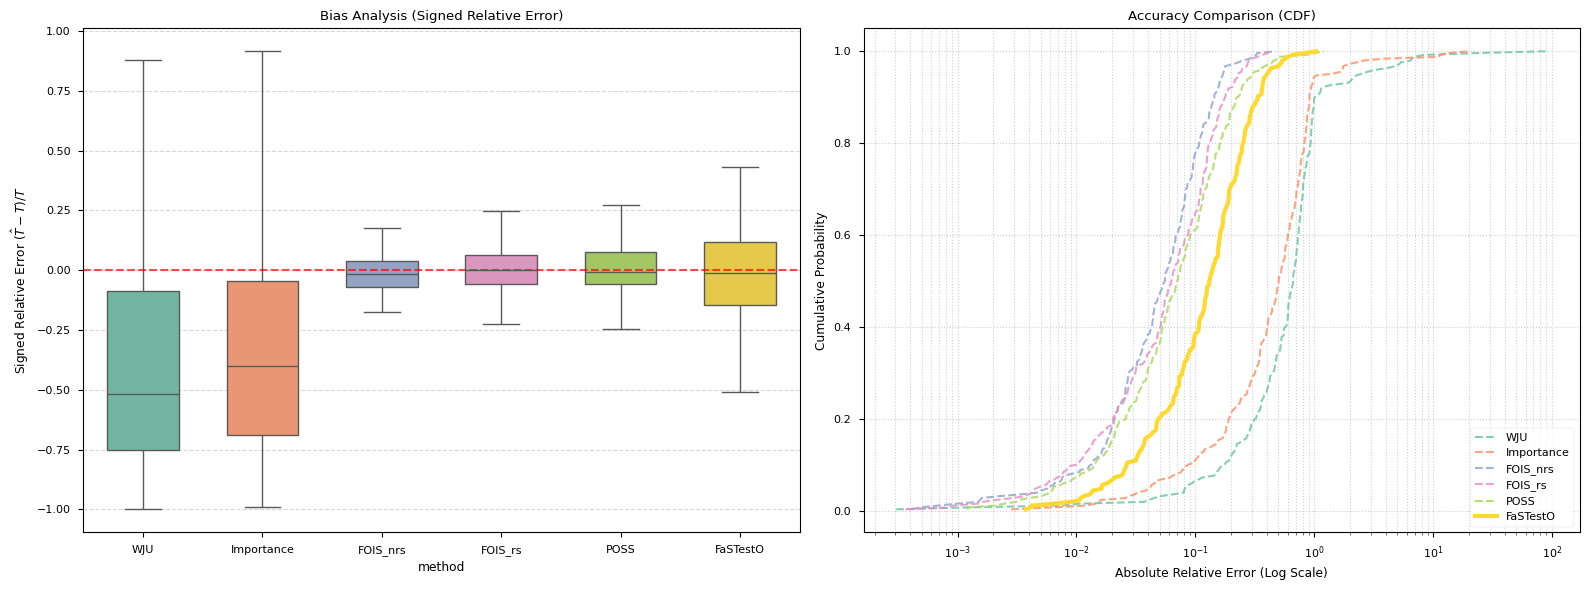

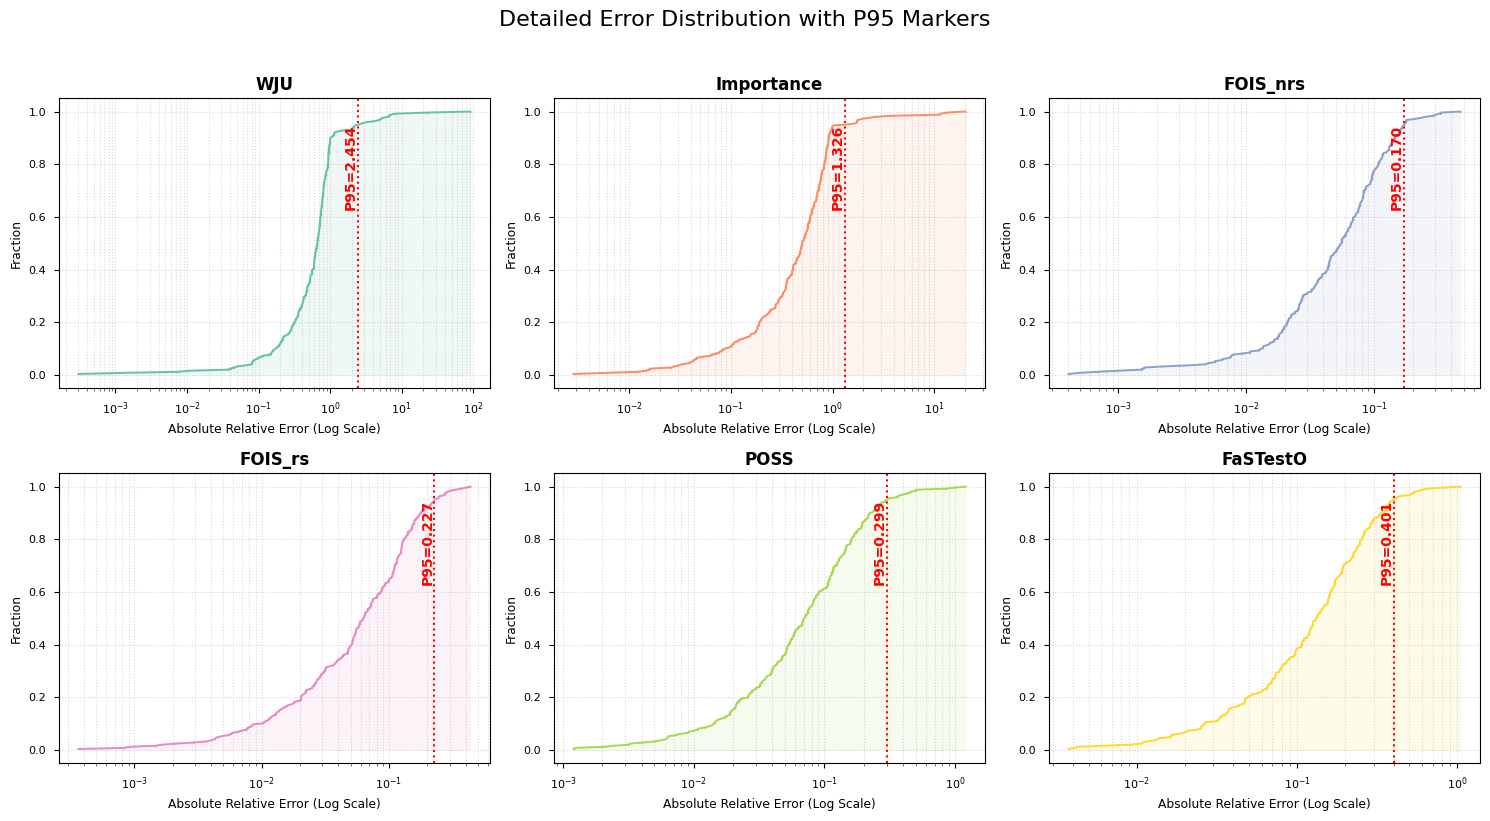


       AQP Evaluation Metrics Summary
Method          | Mean       | Median     | P95        | Max       
-----------------------------------------------------------------
WJU             | 128.22%    |  66.35%    | 245.40%    | 9170.48%
Importance      |  76.38%    |  50.32%    | 132.56%    | 2033.39%
FOIS_nrs        |   7.01%    |   5.55%    |  17.04%    |  47.10%
FOIS_rs         |   8.48%    |   6.33%    |  22.73%    |  43.66%
POSS            |  11.02%    |   7.08%    |  29.93%    | 120.21%
FaSTestO        |  16.52%    |  13.19%    |  40.10%    | 104.39%
-----------------------------------------------------------------


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math

# ==========================================
# 1. 配置路径
# ==========================================
# Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
Distribution = 'ML1_proxy4b_probability'
fatestO = 'results_summary_FaSTestO2.csv'
dataset = 'dataset_three'
# path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_{dataset}.csv"
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_dataset_three.csv"
path_baseline = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/results_summary_run_1.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO}"

methods_wj = ['Uniform', 'Importance'] 
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS']
final_order = ['WJU', 'Importance', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与交集处理
# ==========================================
if not all(os.path.exists(p) for p in [path_wj, path_baseline, path_fastesto]):
    print("Error: 至少有一个文件路径不存在，请检查路径配置。")
else:
    print("正在读取三个文件...")
    df_wj_raw = pd.read_csv(path_wj)
    df_base_raw = pd.read_csv(path_baseline)
    df_fast_raw = pd.read_csv(path_fastesto)

    # 提取交集
    qs_wj = set(df_wj_raw['query_basename'].unique())
    qs_base = set(df_base_raw['query_basename'].unique())
    qs_fast = set(df_fast_raw['query_basename'].unique())
    common_queries = qs_wj.intersection(qs_base).intersection(qs_fast)
    
    print(f"Intersection 查询数: {len(common_queries)}")

    if len(common_queries) == 0:
        print("[Error] 没有共同的查询！")
    else:
        # 数据清洗
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(common_queries)].copy()
        df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(common_queries)].copy()

        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
        df_fast['method'] = 'FaSTestO'

        # 改名 Uniform -> WJU
        df_wj['method'] = df_wj['method'].replace({'Uniform': 'WJU'})

        # 统一 GT
        truth_map = df_base[['query_basename', 'T_true']]\
            .drop_duplicates(subset=['query_basename'])\
            .set_index('query_basename')['T_true']\
            .to_dict()

        valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
        
        df_combined_list = []
        for df in [df_wj, df_base, df_fast]:
            df = df[df['query_basename'].isin(valid_queries)].copy()
            df['T_true'] = df['query_basename'].map(truth_map)
            df_combined_list.append(df[['method', 'T_hat', 'T_true']])

        df_all = pd.concat(df_combined_list, ignore_index=True)

        # ==========================================
        # 3. 计算误差与自适应配置
        # ==========================================
        # SRE: Signed Relative Error (for Boxplot)
        df_all['SRE'] = (df_all['T_hat'] - df_all['T_true']) / df_all['T_true']
        # ARE: Absolute Relative Error (for CDF)
        df_all['ARE'] = df_all['SRE'].abs()

        # --- 自适应逻辑：判断是否使用 Log Scale ---
        max_are = df_all['ARE'].max()
        # 如果最大误差超过 500% (5.0) 或者数据极差非常大，建议开启 Log Scale
        USE_LOG_SCALE = max_are > 5.0 
        
        print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")
        print(f"自适应模式: {'开启 Log Scale' if USE_LOG_SCALE else '使用线性坐标'}")

        # 准备绘图数据 PlotValue
        if USE_LOG_SCALE:
            # log 坐标下 0 会报错，将其替换为极小值 (例如 1e-4)
            df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
            x_label_cdf = "Absolute Relative Error (Log Scale)"
        else:
            df_all['PlotValue'] = df_all['ARE']
            x_label_cdf = "Absolute Relative Error"

        plot_order = [m for m in final_order if m in df_all['method'].unique()]
        
        # 颜色映射
        colors = sns.color_palette("Set2", n_colors=len(plot_order))
        method_colors = dict(zip(plot_order, colors))

        # ==========================================
        # 4. 绘图 Part 1: Boxplot + Combined CDF (综述)
        # ==========================================
        plt.style.use('seaborn-v0_8-paper')
        fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

        # --- 左图: Boxplot (SRE) ---
        sns.boxplot(x="method", y="SRE", data=df_all, order=plot_order,
                    ax=axes[0], palette=method_colors, showfliers=False, width=0.6)
        axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].set_title("Bias Analysis (Signed Relative Error)")
        axes[0].set_ylabel(r"Signed Relative Error $(\hat{T} - T) / T$")
        axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

        # --- 右图: Combined CDF (ARE) ---
        for method in plot_order:
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            
            # 样式：FaSTestO 加粗
            lw = 3.0 if method == 'FaSTestO' else 1.5
            ls = '-' if method == 'FaSTestO' else '--'
            alpha = 1.0 if method == 'FaSTestO' else 0.8
            
            axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                         linewidth=lw, linestyle=ls, alpha=alpha)

        axes[1].set_title("Accuracy Comparison (CDF)")
        axes[1].set_xlabel(x_label_cdf)
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].legend(loc='lower right')
        axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
        
        if USE_LOG_SCALE:
            axes[1].set_xscale('log')
        
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 5. 绘图 Part 2: Detailed Subplots (详情 + P95标注)
        # ==========================================
        # 计算网格布局
        n_methods = len(plot_order)
        cols = 3
        rows = math.ceil(n_methods / cols)

        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle("Detailed Error Distribution with P95 Markers", fontsize=16, y=1.02)

        target_percentiles = [0.95] # 可以添加 [0.90, 0.99]

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            # 绘制曲线和填充
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            # --- 标注 P95 ---
            for p in target_percentiles:
                p_val = subset.quantile(p)
                
                # 画垂线
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                # 画文字
                label_text = f"P{int(p*100)}={p_val:.3f}"
                # 将文字放在图的内部右侧，高度对应 p
                ax.text(p_val, p, label_text, 
                        rotation=90, 
                        color='red', 
                        fontsize=10, 
                        fontweight='bold',
                        verticalalignment='top', 
                        horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            
            if USE_LOG_SCALE:
                ax.set_xscale('log')

        plt.tight_layout()
        plt.show()
        # ==========================================
        # [新增模块] 6. 计算并输出核心评估指标 (Table 1)
        # ==========================================
        print("\n" + "="*50)
        print("       AQP Evaluation Metrics Summary")
        print("="*50)

        # 1. 确保 ARE 已经计算 (基于你之前的代码)
        # df_all['ARE'] = df_all['SRE'].abs()  <-- 你的代码里已经有了

        # 2. 使用 groupby 聚合计算核心指标
        summary_table = df_all.groupby('method')['ARE'].agg(
            Mean_ARE='mean',
            Median_ARE='median',
            P90_ARE=lambda x: x.quantile(0.90),
            P95_ARE=lambda x: x.quantile(0.95), # 最关键指标
            Max_ARE='max'
        )

        # 3. 按照你设定的 final_order 排序
        # 过滤掉不在数据中的方法
        existing_methods = [m for m in final_order if m in summary_table.index]
        summary_table = summary_table.loc[existing_methods]

        # 4. 格式化输出 (转换为百分比显示更直观)
        print(f"{'Method':<15} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 65)

        for method in existing_methods:
            row = summary_table.loc[method]
            print(f"{method:<15} | "
                f"{row['Mean_ARE']*100:6.2f}%    | "
                f"{row['Median_ARE']*100:6.2f}%    | "
                f"{row['P95_ARE']*100:6.2f}%    | "
                f"{row['Max_ARE']*100:6.2f}%")

        print("-" * 65)

##### 5.1.2  我的方法和FastestO\wanderjoin(单推理谓词 )对比

正在读取三个文件...
正在标准化文件名 (去除 .graph 后缀)...
WanderJoin 查询数: 110
Baseline   查询数: 113
FaSTestO   查询数: 113
Intersection (三者交集) 查询数: 110
最大绝对相对误差 (Max ARE): 20.79


/tmp/ipykernel_923278/774421149.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


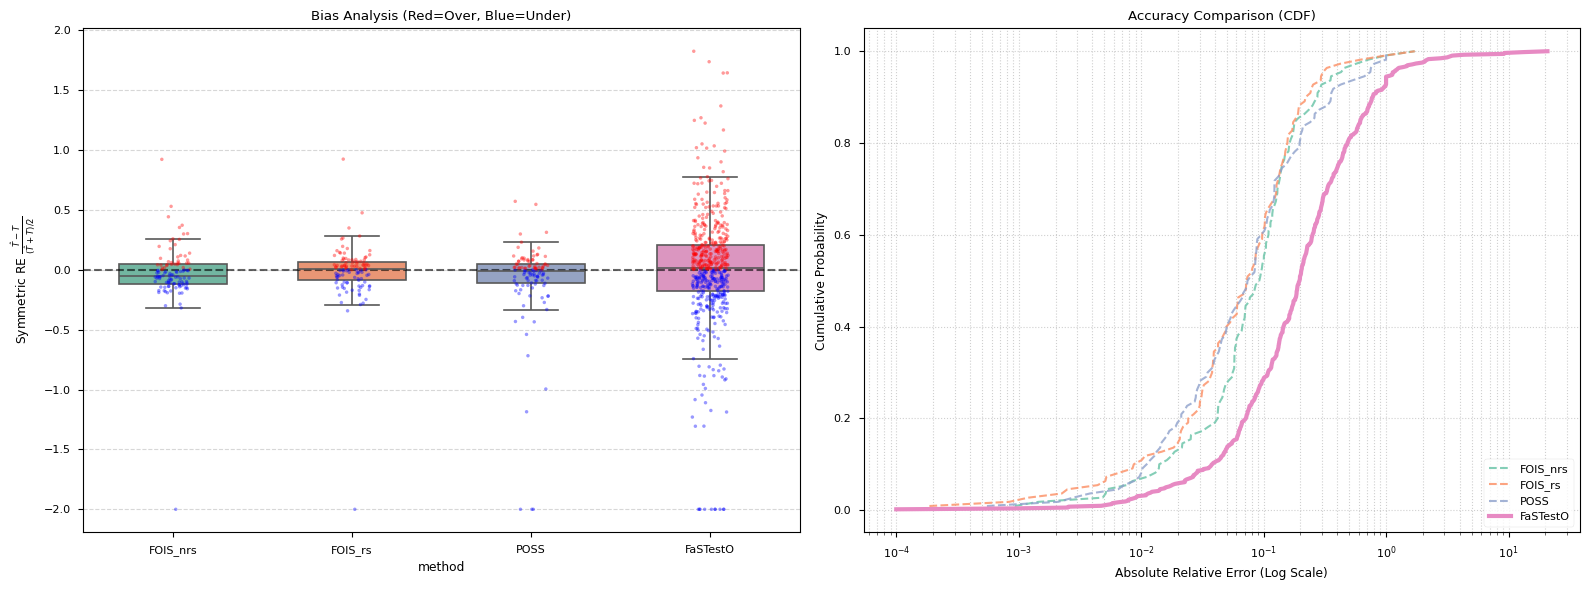

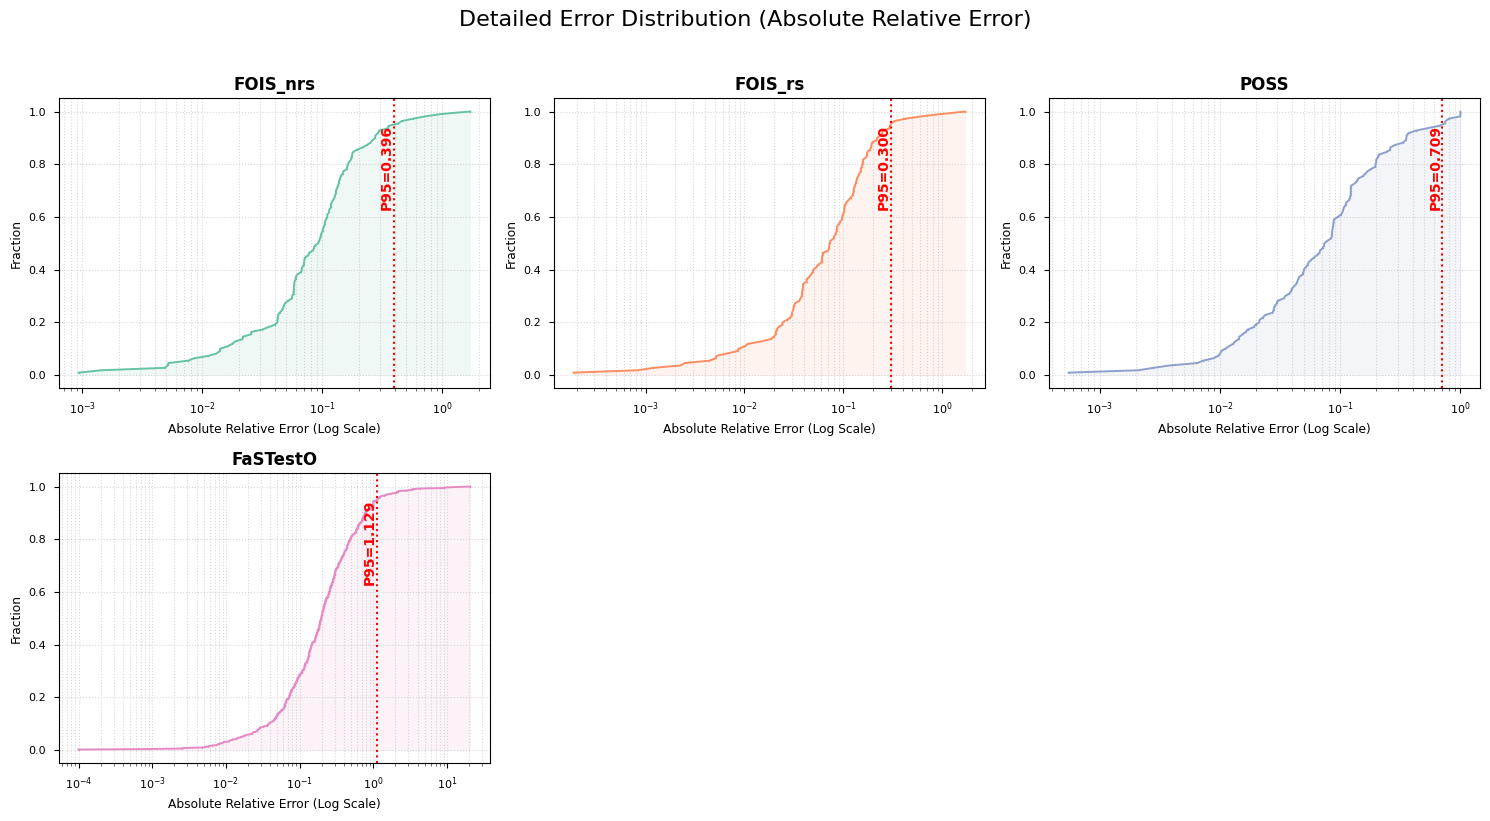


       AQP Evaluation Metrics Summary
Method          | Mean       | Median     | P95        | Max       
-----------------------------------------------------------------
FOIS_nrs        |  13.83%    |   9.31%    |  39.59%    | 171.01%
FOIS_rs         |  12.06%    |   7.33%    |  30.04%    | 171.67%
POSS            |  14.72%    |   7.59%    |  70.86%    | 100.00%
FaSTestO        |  43.24%    |  19.68%    | 112.88%    | 2079.00%
-----------------------------------------------------------------


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math

# ==========================================
# 1. 配置路径
# ==========================================
Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
# Distribution = 'ML1_proxy4b_probability'
fatestO = 'results_summary_FaSTestO.csv'
dataset = 'dataset_test'

# --- [新增] WanderJoin 路径 ---
# path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_dataset_test.csv"
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_dataset_test.csv"
path_baseline = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/results_summary_run_1.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO}"

methods_wj = ['Uniform', 'Importance'] 
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS']
final_order = ['WJU', 'WJP', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================
# 检查三个文件
if not all(os.path.exists(p) for p in [path_wj, path_baseline, path_fastesto]):
    print(f"Error: 至少有一个文件路径不存在，请检查路径配置。")
else:
    print("正在读取三个文件...")
    df_wj_raw = pd.read_csv(path_wj)
    df_base_raw = pd.read_csv(path_baseline)
    df_fast_raw = pd.read_csv(path_fastesto)

    # -----------------------------------------------------------
    # [核心修改] 标准化三个 dataframe 的 query_basename
    # -----------------------------------------------------------
    print("正在标准化文件名 (去除 .graph 后缀)...")
    
    for df in [df_wj_raw, df_base_raw, df_fast_raw]:
        if 'query_basename' in df.columns:
            df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

    # -----------------------------------------------------------

    # 提取交集 (三者交集)
    qs_wj = set(df_wj_raw['query_basename'].unique())
    qs_base = set(df_base_raw['query_basename'].unique())
    qs_fast = set(df_fast_raw['query_basename'].unique())
    
    common_queries = qs_wj.intersection(qs_base).intersection(qs_fast)
    
    print(f"WanderJoin 查询数: {len(qs_wj)}")
    print(f"Baseline   查询数: {len(qs_base)}")
    print(f"FaSTestO   查询数: {len(qs_fast)}")
    print(f"Intersection (三者交集) 查询数: {len(common_queries)}")

    if len(common_queries) == 0:
        print("[Error] 没有共同的查询！请检查 CSV 中的 query_basename 列。")
    else:
        # 数据清洗 (只保留交集)
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(common_queries)].copy()
        df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(common_queries)].copy()

        # 筛选方法与改名
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        df_wj['method'] = df_wj['method'].replace({'Uniform': 'WJU', 'Importance': 'WJP'}) # 改名
        
        df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
        
        df_fast['method'] = 'FaSTestO'

        # 统一 GT (Ground Truth) - 以 Baseline 为准
        truth_map = df_base[['query_basename', 'T_true']]\
            .drop_duplicates(subset=['query_basename'])\
            .set_index('query_basename')['T_true']\
            .to_dict()

        valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
        
        # 合并数据
        df_combined_list = []
        for df in [df_wj, df_base, df_fast]:
            df = df[df['query_basename'].isin(valid_queries)].copy()
            # 重新映射 T_true 以确保完全对齐
            df['T_true'] = df['query_basename'].map(truth_map)
            df_combined_list.append(df[['method', 'T_hat', 'T_true']])

        df_all = pd.concat(df_combined_list, ignore_index=True)

        # ==========================================
        # 3. 计算误差
        # ==========================================
        epsilon = 1e-9 

        # --- A. 对称相对误差 (SymRE) -> 用于 Bias (Boxplot) ---
        # SymRE > 0 表示高估，SymRE < 0 表示低估
        df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)

        # --- B. 绝对相对误差 (ARE) -> 用于 Accuracy (CDF) ---
        df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

        # 自适应 Log Scale
        max_are = df_all['ARE'].max()
        USE_LOG_SCALE = max_are > 5.0 
        
        print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

        if USE_LOG_SCALE:
            df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
            x_label_cdf = "Absolute Relative Error (Log Scale)"
        else:
            df_all['PlotValue'] = df_all['ARE']
            x_label_cdf = "Absolute Relative Error"

        plot_order = [m for m in final_order if m in df_all['method'].unique()]
        colors = sns.color_palette("Set2", n_colors=len(plot_order))
        method_colors = dict(zip(plot_order, colors))

        # ==========================================
        # 4. 绘图 Part 1: Bias Analysis (SymRE) + Accuracy (CDF)
        # ==========================================
        
        # --- 配置开关 ---
        SHOW_ALL_POINTS = True     # 开启点图
        SHOW_OUTLIERS = False      # 如果显示了所有点，通常关闭箱型图自带的离群点，以免重复

        plt.style.use('seaborn-v0_8-paper')
        fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

        # --- 左图: Bias (Boxplot 使用 SymRE) ---
        sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                    ax=axes[0], palette=method_colors, 
                    showfliers=SHOW_OUTLIERS, # 控制箱型图自带的黑钻离群点
                    width=0.6, linewidth=1.2)
        
        # [修改点] 绘制红/蓝散点
        if SHOW_ALL_POINTS:
            # 1. 创建颜色分类列
            # High (高估) -> Red, Low (低估) -> Blue
            df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
            
            # 2. 使用 stripplot 的 hue 功能
            # dodge=False 确保点都画在箱子中间，不因为颜色不同而左右分开
            sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                          ax=axes[0], 
                          hue="EstimationType", 
                          palette={'High': 'red', 'Low': 'blue'},
                          size=2.5, alpha=0.4, jitter=True, 
                          dodge=False, legend=False)

        # 0 线 (无偏差)
        axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        axes[0].set_title("Bias Analysis (Red=Over, Blue=Under)")
        axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
        axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

        # --- 右图: Accuracy (CDF 使用 ARE) ---
        for method in plot_order:
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            
            # FaSTestO 突出显示
            lw = 3.0 if method == 'FaSTestO' else 1.5
            ls = '-' if method == 'FaSTestO' else '--'
            alpha = 1.0 if method == 'FaSTestO' else 0.8
            
            axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                         linewidth=lw, linestyle=ls, alpha=alpha)

        axes[1].set_title("Accuracy Comparison (CDF)")
        axes[1].set_xlabel(x_label_cdf)
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].legend(loc='lower right')
        axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
        
        if USE_LOG_SCALE:
            axes[1].set_xscale('log')
        
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 5. 绘图 Part 2: Detailed Subplots (ARE)
        # ==========================================
        cols = min(len(plot_order), 3)
        rows = math.ceil(len(plot_order) / cols)    

        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle("Detailed Error Distribution (Absolute Relative Error)", fontsize=16, y=1.02)
        target_percentiles = [0.95] # 只标P95，或者加 [0.5, 0.95]

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            for p in target_percentiles:
                p_val = subset.quantile(p)
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                        rotation=90, color='red', fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            
            if USE_LOG_SCALE:
                ax.set_xscale('log')

        plt.tight_layout()
        plt.show()

        # ==========================================
        # 6. 计算并输出核心评估指标 (Table 1)
        # ==========================================
        print("\n" + "="*50)
        print("       AQP Evaluation Metrics Summary")
        print("="*50)

        summary_table = df_all.groupby('method')['ARE'].agg(
            Mean_ARE='mean',
            Median_ARE='median',
            P95_ARE=lambda x: x.quantile(0.95), 
            Max_ARE='max'
        )

        existing_methods = [m for m in final_order if m in summary_table.index]
        summary_table = summary_table.loc[existing_methods]

        print(f"{'Method':<15} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 65)

        for method in existing_methods:
            row = summary_table.loc[method]
            print(f"{method:<15} | "
                f"{row['Mean_ARE']*100:6.2f}%    | "
                f"{row['Median_ARE']*100:6.2f}%    | "
                f"{row['P95_ARE']*100:6.2f}%    | "
                f"{row['Max_ARE']*100:6.2f}%")

        print("-" * 65)

##### 5.1.3  我的方法和FastestO\wanderjoin(多推理谓词 )对比

正在读取三个文件...
正在标准化文件名 (去除 .graph 后缀)...
WanderJoin 查询数: 110
Baseline   查询数: 113
FaSTestO   查询数: 113
Intersection (三者交集) 查询数: 110
最大绝对相对误差 (Max ARE): 107.21


/tmp/ipykernel_923278/2816363680.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


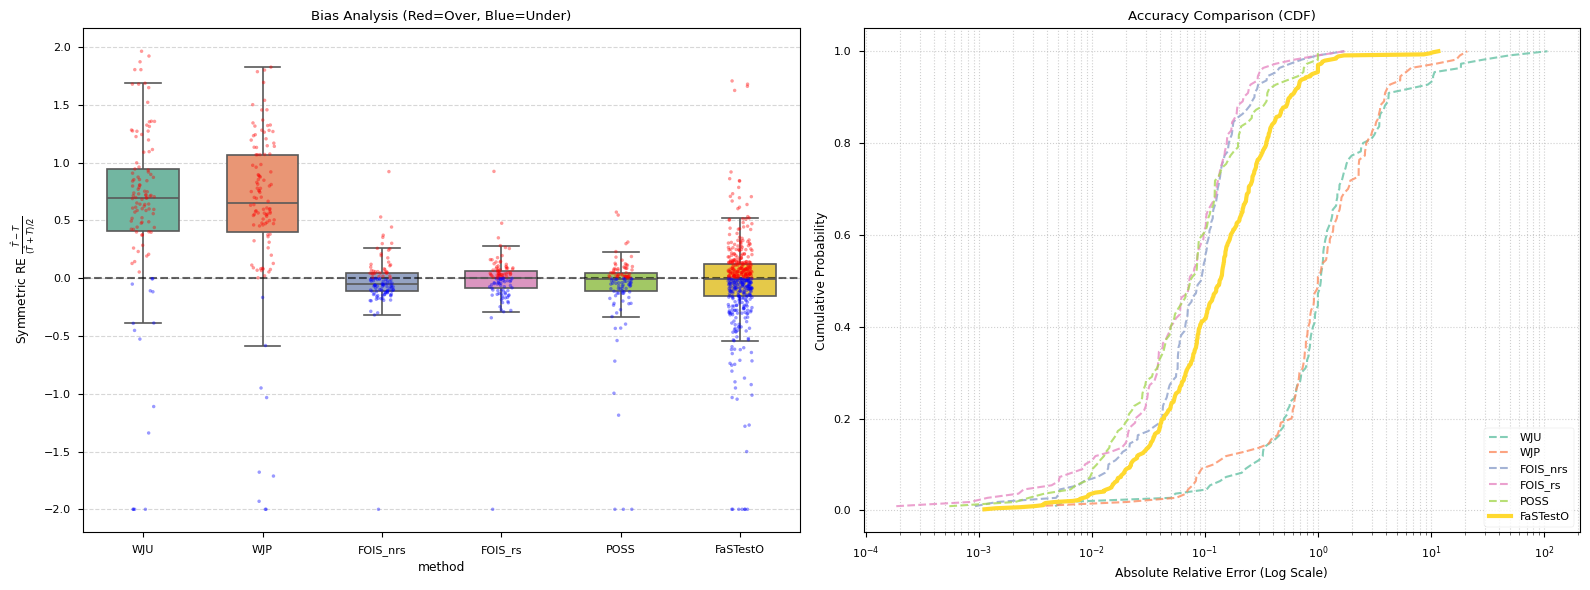

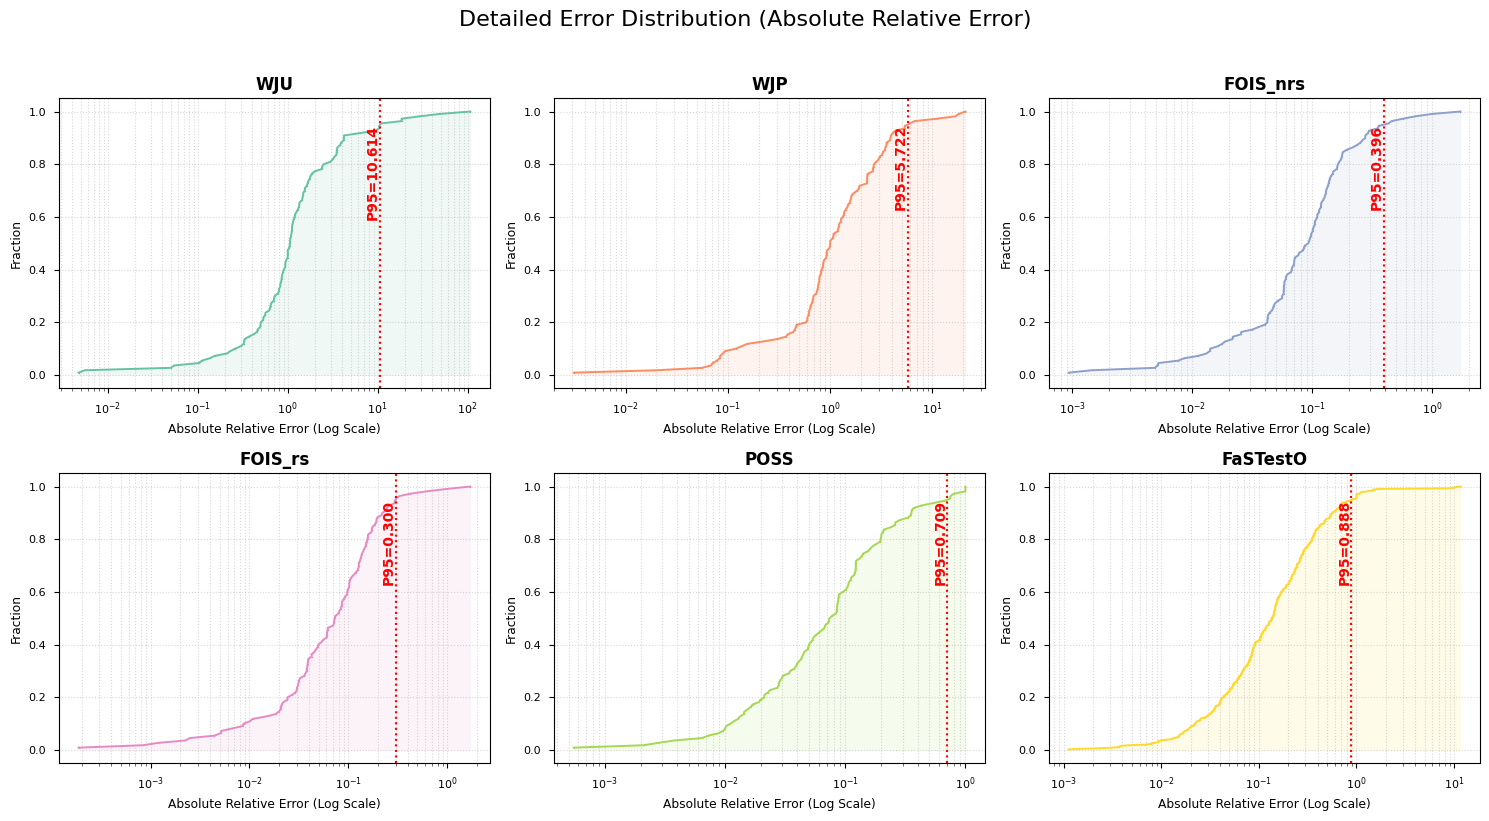


       AQP Evaluation Metrics Summary
Method          | Mean       | Median     | P95        | Max       
-----------------------------------------------------------------
WJU             | 359.43%    | 106.22%    | 1061.44%    | 10721.32%
WJP             | 205.26%    | 100.00%    | 572.23%    | 2097.51%
FOIS_nrs        |  13.83%    |   9.31%    |  39.59%    | 171.01%
FOIS_rs         |  12.06%    |   7.33%    |  30.04%    | 171.67%
POSS            |  14.72%    |   7.59%    |  70.86%    | 100.00%
FaSTestO        |  31.28%    |  13.58%    |  88.80%    | 1162.94%
-----------------------------------------------------------------


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math

# ==========================================
# 1. 配置路径
# ==========================================
Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
# Distribution = 'ML1_proxy4b_probability'
fatestO = 'results_summary_FaSTestO.csv'
dataset = 'dataset_test'

# --- [新增] WanderJoin 路径 ---
# path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_dataset_test.csv"
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_dataset_test.csv"
path_baseline = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/results_summary_run_1.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO}"

# methods_wj = ['Uniform', 'Importance'] 
methods_wj = ['WJ_uniform_multi', 'WJ_importance_multi']
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS']
final_order = ['WJU', 'WJP', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================
# 检查三个文件
if not all(os.path.exists(p) for p in [path_wj, path_baseline, path_fastesto]):
    print(f"Error: 至少有一个文件路径不存在，请检查路径配置。")
else:
    print("正在读取三个文件...")
    df_wj_raw = pd.read_csv(path_wj)
    df_base_raw = pd.read_csv(path_baseline)
    df_fast_raw = pd.read_csv(path_fastesto)

    # -----------------------------------------------------------
    # [核心修改] 标准化三个 dataframe 的 query_basename
    # -----------------------------------------------------------
    print("正在标准化文件名 (去除 .graph 后缀)...")
    
    for df in [df_wj_raw, df_base_raw, df_fast_raw]:
        if 'query_basename' in df.columns:
            df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

    # -----------------------------------------------------------

    # 提取交集 (三者交集)
    qs_wj = set(df_wj_raw['query_basename'].unique())
    qs_base = set(df_base_raw['query_basename'].unique())
    qs_fast = set(df_fast_raw['query_basename'].unique())
    
    common_queries = qs_wj.intersection(qs_base).intersection(qs_fast)
    
    print(f"WanderJoin 查询数: {len(qs_wj)}")
    print(f"Baseline   查询数: {len(qs_base)}")
    print(f"FaSTestO   查询数: {len(qs_fast)}")
    print(f"Intersection (三者交集) 查询数: {len(common_queries)}")

    if len(common_queries) == 0:
        print("[Error] 没有共同的查询！请检查 CSV 中的 query_basename 列。")
    else:
        # 数据清洗 (只保留交集)
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(common_queries)].copy()
        df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(common_queries)].copy()

        # 筛选方法与改名
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        # df_wj['method'] = df_wj['method'].replace({'Uniform': 'WJU', 'Importance': 'WJP'}) # 改名
        df_wj['method'] = df_wj['method'].replace({
            'WJ_uniform_multi': 'WJU', 
            'WJ_importance_multi': 'WJP'
        })
        
        df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
        
        df_fast['method'] = 'FaSTestO'

        # 统一 GT (Ground Truth) - 以 Baseline 为准
        truth_map = df_base[['query_basename', 'T_true']]\
            .drop_duplicates(subset=['query_basename'])\
            .set_index('query_basename')['T_true']\
            .to_dict()

        valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
        
        # 合并数据
        df_combined_list = []
        for df in [df_wj, df_base, df_fast]:
            df = df[df['query_basename'].isin(valid_queries)].copy()
            # 重新映射 T_true 以确保完全对齐
            df['T_true'] = df['query_basename'].map(truth_map)
            df_combined_list.append(df[['method', 'T_hat', 'T_true']])

        df_all = pd.concat(df_combined_list, ignore_index=True)

        # ==========================================
        # 3. 计算误差
        # ==========================================
        epsilon = 1e-9 

        # --- A. 对称相对误差 (SymRE) -> 用于 Bias (Boxplot) ---
        # SymRE > 0 表示高估，SymRE < 0 表示低估
        df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)

        # --- B. 绝对相对误差 (ARE) -> 用于 Accuracy (CDF) ---
        df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

        # 自适应 Log Scale
        max_are = df_all['ARE'].max()
        USE_LOG_SCALE = max_are > 5.0 
        
        print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

        if USE_LOG_SCALE:
            df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
            x_label_cdf = "Absolute Relative Error (Log Scale)"
        else:
            df_all['PlotValue'] = df_all['ARE']
            x_label_cdf = "Absolute Relative Error"

        plot_order = [m for m in final_order if m in df_all['method'].unique()]
        colors = sns.color_palette("Set2", n_colors=len(plot_order))
        method_colors = dict(zip(plot_order, colors))

        # ==========================================
        # 4. 绘图 Part 1: Bias Analysis (SymRE) + Accuracy (CDF)
        # ==========================================
        
        # --- 配置开关 ---
        SHOW_ALL_POINTS = True     # 开启点图
        SHOW_OUTLIERS = False      # 如果显示了所有点，通常关闭箱型图自带的离群点，以免重复

        plt.style.use('seaborn-v0_8-paper')
        fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

        # --- 左图: Bias (Boxplot 使用 SymRE) ---
        sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                    ax=axes[0], palette=method_colors, 
                    showfliers=SHOW_OUTLIERS, # 控制箱型图自带的黑钻离群点
                    width=0.6, linewidth=1.2)
        
        # [修改点] 绘制红/蓝散点
        if SHOW_ALL_POINTS:
            # 1. 创建颜色分类列
            # High (高估) -> Red, Low (低估) -> Blue
            df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
            
            # 2. 使用 stripplot 的 hue 功能
            # dodge=False 确保点都画在箱子中间，不因为颜色不同而左右分开
            sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                          ax=axes[0], 
                          hue="EstimationType", 
                          palette={'High': 'red', 'Low': 'blue'},
                          size=2.5, alpha=0.4, jitter=True, 
                          dodge=False, legend=False)

        # 0 线 (无偏差)
        axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        axes[0].set_title("Bias Analysis (Red=Over, Blue=Under)")
        axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
        axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

        # --- 右图: Accuracy (CDF 使用 ARE) ---
        for method in plot_order:
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            
            # FaSTestO 突出显示
            lw = 3.0 if method == 'FaSTestO' else 1.5
            ls = '-' if method == 'FaSTestO' else '--'
            alpha = 1.0 if method == 'FaSTestO' else 0.8
            
            axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                         linewidth=lw, linestyle=ls, alpha=alpha)

        axes[1].set_title("Accuracy Comparison (CDF)")
        axes[1].set_xlabel(x_label_cdf)
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].legend(loc='lower right')
        axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
        
        if USE_LOG_SCALE:
            axes[1].set_xscale('log')
        
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 5. 绘图 Part 2: Detailed Subplots (ARE)
        # ==========================================
        cols = min(len(plot_order), 3)
        rows = math.ceil(len(plot_order) / cols)    

        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle("Detailed Error Distribution (Absolute Relative Error)", fontsize=16, y=1.02)
        target_percentiles = [0.95] # 只标P95，或者加 [0.5, 0.95]

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            for p in target_percentiles:
                p_val = subset.quantile(p)
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                        rotation=90, color='red', fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            
            if USE_LOG_SCALE:
                ax.set_xscale('log')

        plt.tight_layout()
        plt.show()

        # ==========================================
        # 6. 计算并输出核心评估指标 (Table 1)
        # ==========================================
        print("\n" + "="*50)
        print("       AQP Evaluation Metrics Summary")
        print("="*50)

        summary_table = df_all.groupby('method')['ARE'].agg(
            Mean_ARE='mean',
            Median_ARE='median',
            P95_ARE=lambda x: x.quantile(0.95), 
            Max_ARE='max'
        )

        existing_methods = [m for m in final_order if m in summary_table.index]
        summary_table = summary_table.loc[existing_methods]

        print(f"{'Method':<15} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 65)

        for method in existing_methods:
            row = summary_table.loc[method]
            print(f"{method:<15} | "
                f"{row['Mean_ARE']*100:6.2f}%    | "
                f"{row['Median_ARE']*100:6.2f}%    | "
                f"{row['P95_ARE']*100:6.2f}%    | "
                f"{row['Max_ARE']*100:6.2f}%")

        print("-" * 65)

##### 5.1.4  对于我的方法随机取result_summarys下的n个results_summary_run_x.csv文件参与计算箱型图和CDF图以及 AQP Evaluation Metrics Summary

正在从目录中随机抽取 1 个 Baseline 文件...
已选中文件: ['results_summary_run_11.csv']
Baseline 数据加载完成，共 5088 行。
正在标准化文件名 (去除 .graph 后缀)...
WanderJoin 查询数: 246
Baseline   查询数 (Unique): 246
FaSTestO   查询数: 246
Intersection (三者交集) 查询数: 246
最大绝对相对误差 (Max ARE): 71.19


/tmp/ipykernel_923278/977722569.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


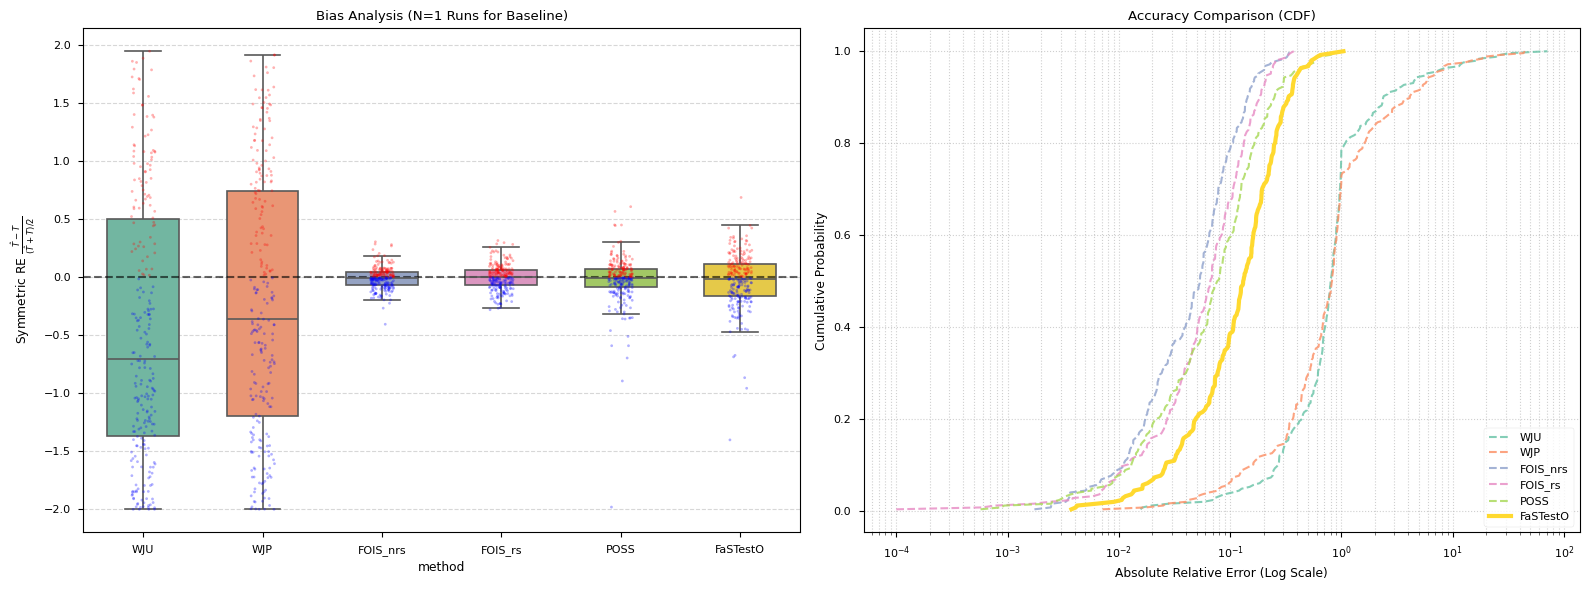

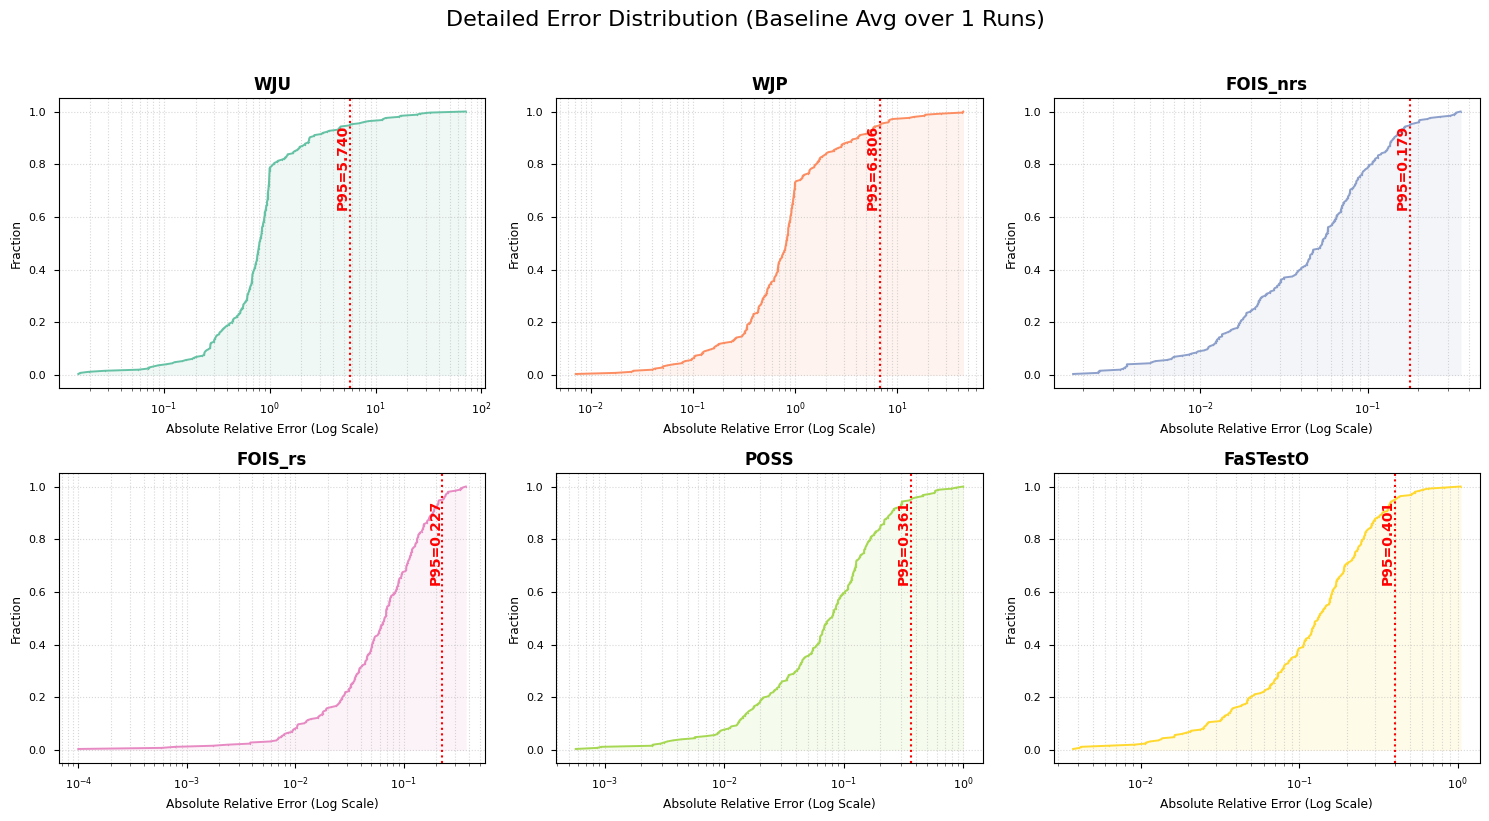


       AQP Evaluation Metrics Summary
Note: Baseline metrics are calculated over 1 randomly selected runs.
Method               | Mean       | Median     | P95        | Max       
----------------------------------------------------------------------
WJU                  | 191.03%    |  80.10%    | 573.97%    | 7119.09%
WJP                  | 194.95%    |  82.41%    | 680.65%    | 4453.36%
FOIS_nrs             |   6.77%    |   5.35%    |  17.88%    |  35.84%
FOIS_rs              |   8.50%    |   6.68%    |  22.70%    |  37.37%
POSS                 |  11.70%    |   7.83%    |  36.14%    |  99.52%
FaSTestO             |  16.52%    |  13.19%    |  40.10%    | 104.39%
----------------------------------------------------------------------


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import random  # [新增] 用于随机采样

# ==========================================
# 1. 配置路径与采样设置
# ==========================================
# Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
Distribution = 'ML1_proxy4b_probability'
fatestO = 'results_summary_FaSTestO.csv'
dataset = 'dataset_three'

# --- 采样设置 [核心修改] ---
N_SAMPLES = 1  # [配置] 随机选取多少个 run 文件参与计算

# --- 路径配置 ---
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_dataset_three.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO}"

# [修改] 这里改为目录路径，而不是具体文件
baseline_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/"

# 方法定义
methods_wj = ['WJ_uniform_multi', 'WJ_importance_multi']
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS']
final_order = ['WJU', 'WJP', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================
# 1. 检查文件与目录
if not os.path.exists(path_wj) or not os.path.exists(path_fastesto) or not os.path.exists(baseline_dir):
    print(f"Error: 路径不存在，请检查配置。")
    print(f"WJ: {path_wj}")
    print(f"BaseDir: {baseline_dir}")
else:
    # -----------------------------------------------------------
    # [核心修改] 随机读取 N 个 Baseline 文件并合并
    # -----------------------------------------------------------
    print(f"正在从目录中随机抽取 {N_SAMPLES} 个 Baseline 文件...")
    
    # 获取目录下所有符合格式的文件
    all_files = [f for f in os.listdir(baseline_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]
    
    if len(all_files) < N_SAMPLES:
        print(f"[Warning] 目录下只有 {len(all_files)} 个文件，少于要求的 {N_SAMPLES}，将全部使用。")
        selected_files = all_files
    else:
        selected_files = random.sample(all_files, N_SAMPLES)
        
    print(f"已选中文件: {selected_files}")

    # 循环读取并合并
    df_base_list = []
    for f in selected_files:
        path = os.path.join(baseline_dir, f)
        try:
            temp_df = pd.read_csv(path)
            # 可选：标记来源文件（方便调试，不影响计算）
            temp_df['source_run'] = f 
            df_base_list.append(temp_df)
        except Exception as e:
            print(f"读取文件 {f} 失败: {e}")

    if not df_base_list:
        print("Error: 没有成功读取任何 Baseline 文件！")
        exit()

    df_base_raw = pd.concat(df_base_list, ignore_index=True)
    print(f"Baseline 数据加载完成，共 {len(df_base_raw)} 行。")

    # 读取其他两个文件
    df_wj_raw = pd.read_csv(path_wj)
    df_fast_raw = pd.read_csv(path_fastesto)

    # -----------------------------------------------------------
    # 标准化文件名 (去除 .graph 后缀)
    # -----------------------------------------------------------
    print("正在标准化文件名 (去除 .graph 后缀)...")
    for df in [df_wj_raw, df_base_raw, df_fast_raw]:
        if 'query_basename' in df.columns:
            df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

    # -----------------------------------------------------------
    # 提取交集 (三者交集)
    # -----------------------------------------------------------
    qs_wj = set(df_wj_raw['query_basename'].unique())
    qs_base = set(df_base_raw['query_basename'].unique())
    qs_fast = set(df_fast_raw['query_basename'].unique())
    
    common_queries = qs_wj.intersection(qs_base).intersection(qs_fast)
    
    print(f"WanderJoin 查询数: {len(qs_wj)}")
    print(f"Baseline   查询数 (Unique): {len(qs_base)}")
    print(f"FaSTestO   查询数: {len(qs_fast)}")
    print(f"Intersection (三者交集) 查询数: {len(common_queries)}")

    if len(common_queries) == 0:
        print("[Error] 没有共同的查询！请检查 CSV 中的 query_basename 列。")
    else:
        # 数据清洗 (只保留交集)
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(common_queries)].copy()
        df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(common_queries)].copy()

        # 筛选方法与改名
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        df_wj['method'] = df_wj['method'].replace({
            'WJ_uniform_multi': 'WJU', 
            'WJ_importance_multi': 'WJP'
        })
        
        df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
        df_fast['method'] = 'FaSTestO'

        # 统一 GT (Ground Truth) - 以 Baseline 为准
        # [注意] 因为合并了多个 Run，baseline 里会有重复的 query，需要 drop_duplicates 取唯一的 GT
        truth_map = df_base[['query_basename', 'T_true']]\
            .drop_duplicates(subset=['query_basename'])\
            .set_index('query_basename')['T_true']\
            .to_dict()

        valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
        
        # 合并数据
        df_combined_list = []
        for df in [df_wj, df_base, df_fast]:
            df = df[df['query_basename'].isin(valid_queries)].copy()
            # 重新映射 T_true 以确保完全对齐
            df['T_true'] = df['query_basename'].map(truth_map)
            df_combined_list.append(df[['method', 'T_hat', 'T_true']])

        df_all = pd.concat(df_combined_list, ignore_index=True)

        # ==========================================
        # 3. 计算误差
        # ==========================================
        epsilon = 1e-9 
        # SymRE
        df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)
        # ARE
        df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

        max_are = df_all['ARE'].max()
        USE_LOG_SCALE = max_are > 5.0 
        print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

        if USE_LOG_SCALE:
            df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
            x_label_cdf = "Absolute Relative Error (Log Scale)"
        else:
            df_all['PlotValue'] = df_all['ARE']
            x_label_cdf = "Absolute Relative Error"

        plot_order = [m for m in final_order if m in df_all['method'].unique()]
        colors = sns.color_palette("Set2", n_colors=len(plot_order))
        method_colors = dict(zip(plot_order, colors))

        # ==========================================
        # 4. 绘图 Part 1: Bias + CDF
        # ==========================================
        SHOW_ALL_POINTS = True     
        SHOW_OUTLIERS = False      

        plt.style.use('seaborn-v0_8-paper')
        fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Boxplot
        sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                    ax=axes[0], palette=method_colors, 
                    showfliers=SHOW_OUTLIERS, width=0.6, linewidth=1.2)
        
        if SHOW_ALL_POINTS:
            df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
            # 此时 Baseline 的点会变多（因为包含多个 Run），这能真实反映算法的稳定性
            sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                          ax=axes[0], hue="EstimationType", 
                          palette={'High': 'red', 'Low': 'blue'},
                          size=2.0, alpha=0.3, jitter=True, dodge=False, legend=False)

        axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        axes[0].set_title(f"Bias Analysis (N={N_SAMPLES} Runs for Baseline)")
        axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
        axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

        # CDF
        for method in plot_order:
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            
            lw = 3.0 if method == 'FaSTestO' else 1.5
            ls = '-' if method == 'FaSTestO' else '--'
            alpha = 1.0 if method == 'FaSTestO' else 0.8
            
            axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                         linewidth=lw, linestyle=ls, alpha=alpha)

        axes[1].set_title("Accuracy Comparison (CDF)")
        axes[1].set_xlabel(x_label_cdf)
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].legend(loc='lower right')
        axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
        if USE_LOG_SCALE: axes[1].set_xscale('log')
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 5. 绘图 Part 2: Detailed Subplots
        # ==========================================
        cols = min(len(plot_order), 3)
        if cols > 0:
            rows = math.ceil(len(plot_order) / cols)    
            fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
            fig2.suptitle(f"Detailed Error Distribution (Baseline Avg over {N_SAMPLES} Runs)", fontsize=16, y=1.02)
            target_percentiles = [0.95] 

            for idx, method in enumerate(plot_order):
                ax = plt.subplot(rows, cols, idx + 1)
                subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
                if subset.empty: continue
                
                y_vals = np.arange(1, len(subset) + 1) / len(subset)
                color = method_colors[method]
                
                ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
                ax.fill_between(subset, y_vals, color=color, alpha=0.1)
                
                for p in target_percentiles:
                    p_val = subset.quantile(p)
                    ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                    ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                            rotation=90, color='red', fontsize=10, fontweight='bold',
                            verticalalignment='top', horizontalalignment='right')

                ax.set_title(f"{method}", fontsize=12, fontweight='bold')
                ax.set_xlabel(x_label_cdf)
                ax.set_ylabel("Fraction")
                ax.grid(True, which="both", linestyle=':', alpha=0.5)
                if USE_LOG_SCALE: ax.set_xscale('log')

            plt.tight_layout()
            plt.show()

        # ==========================================
        # 6. 表格输出
        # ==========================================
        print("\n" + "="*50)
        print("       AQP Evaluation Metrics Summary")
        print("="*50)
        print(f"Note: Baseline metrics are calculated over {N_SAMPLES} randomly selected runs.")
        
        summary_table = df_all.groupby('method')['ARE'].agg(
            Mean_ARE='mean', Median_ARE='median',
            P95_ARE=lambda x: x.quantile(0.95), Max_ARE='max'
        )
        existing_methods = [m for m in final_order if m in summary_table.index]
        summary_table = summary_table.loc[existing_methods]
        
        print(f"{'Method':<20} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 70)
        for method in existing_methods:
            row = summary_table.loc[method]
            print(f"{method:<20} | {row['Mean_ARE']*100:6.2f}%    | {row['Median_ARE']*100:6.2f}%    | {row['P95_ARE']*100:6.2f}%    | {row['Max_ARE']*100:6.2f}%")
        print("-" * 70)

##### 5.1.5 在顶部添加了 ENABLE_WANDERJOIN 和 ENABLE_FASTESTO 两个布尔变量。你可以设置为 True 或 False 来决定是否读取并对比这两个文件

正在从目录中随机抽取 20 个 Baseline 文件...
已选中 Baseline 文件: ['results_summary_run_7.csv', 'results_summary_run_4.csv', 'results_summary_run_1.csv', 'results_summary_run_3.csv', 'results_summary_run_18.csv', 'results_summary_run_19.csv', 'results_summary_run_12.csv', 'results_summary_run_10.csv', 'results_summary_run_11.csv', 'results_summary_run_15.csv', 'results_summary_run_20.csv', 'results_summary_run_17.csv', 'results_summary_run_2.csv', 'results_summary_run_9.csv', 'results_summary_run_14.csv', 'results_summary_run_16.csv', 'results_summary_run_8.csv', 'results_summary_run_6.csv', 'results_summary_run_5.csv', 'results_summary_run_13.csv']
Baseline 数据加载完成，共 101760 行。
正在读取 FaSTestO: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/results_summary_FaSTestO.csv
正在标准化 query_basename...
FaSTestO   查询数: 246
Baseline   查询数 (Unique): 246
==> 最终交集查询数: 246
最大绝对相对误差 (Max ARE): 5.07


/tmp/ipykernel_2608150/3332049284.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


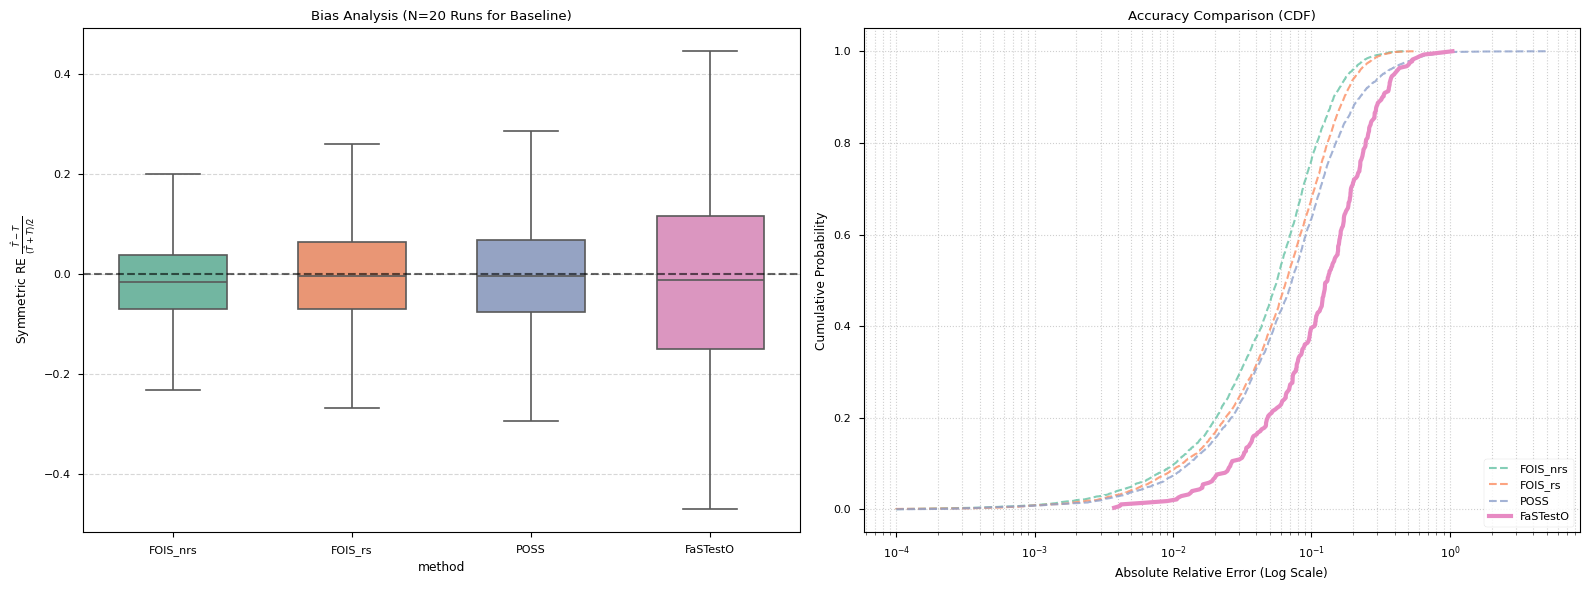

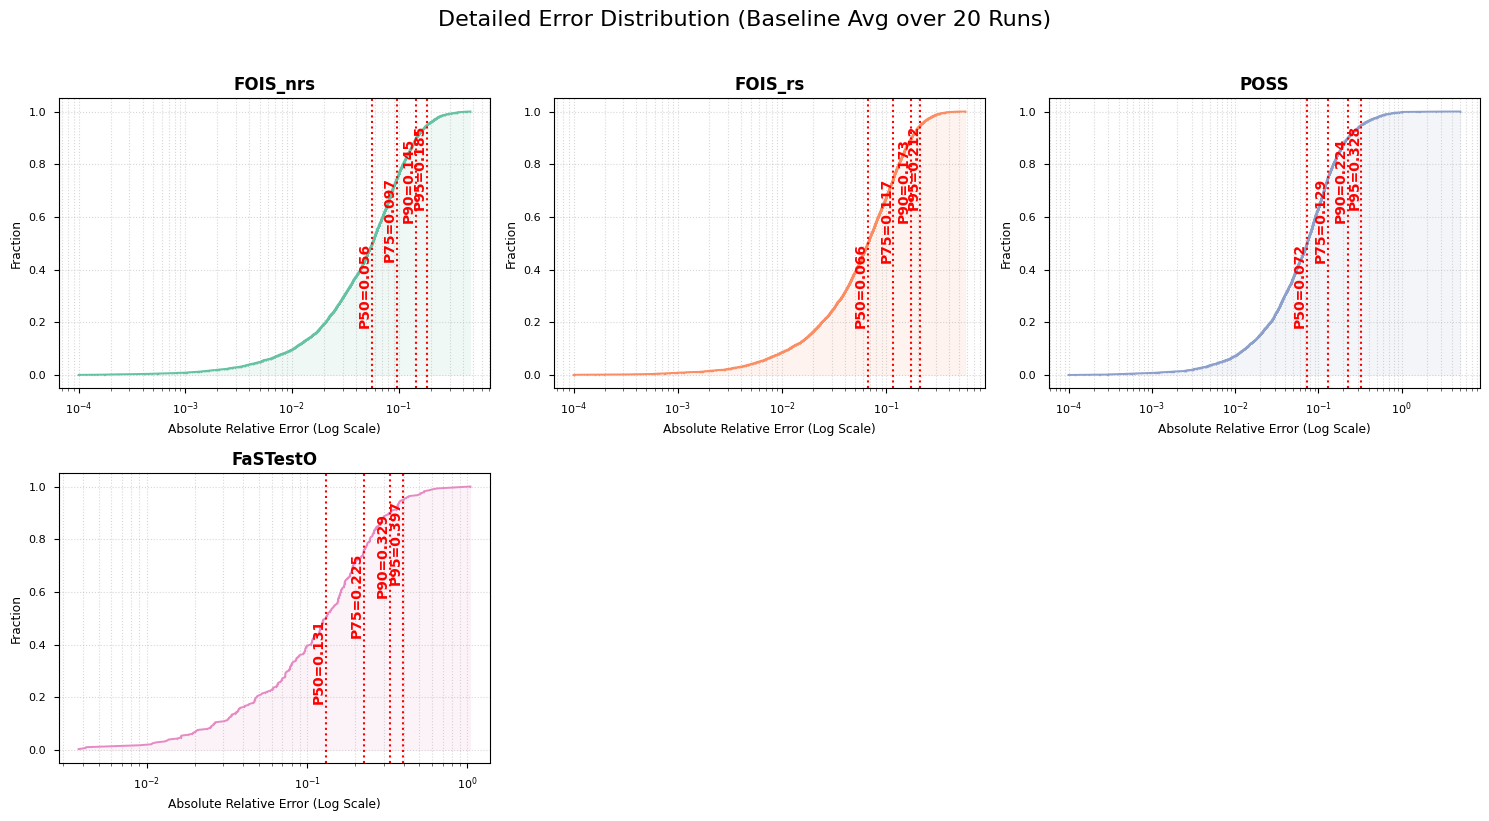


       AQP Evaluation Metrics Summary (Dynamic Percentiles)
Method               | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------------
FOIS_nrs             |      7.03% |      5.65% |      5.65% |      9.69% |     14.51% |     18.51% |     47.10%
FOIS_rs              |      8.25% |      6.61% |      6.61% |     11.70% |     17.31% |     21.16% |     57.33%
POSS                 |     10.87% |      7.24% |      7.24% |     12.95% |     22.43% |     32.76% |    507.11%
FaSTestO             |     16.23% |     13.10% |     13.10% |     22.49% |     32.85% |     39.68% |    104.39%
---------------------------------------------------------------------------------------------------------------


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import random

# ==========================================
# 1. 配置路径与采样设置
# ==========================================
# Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
Distribution = 'ML1_proxy4b_probability'
dataset = 'dataset_three'
fatestO_file = 'results_summary_FaSTestO.csv'

# --- [用户配置区] 是否启用对比 ---
ENABLE_WANDERJOIN = False   # 是否包含 WanderJoin 结果
ENABLE_FASTESTO = True      # 是否包含 FaSTestO 结果
SHOW_ALL_POINTS = False    
SHOW_OUTLIERS = False   
# --- 采样设置 ---
N_SAMPLES = 20  # 随机选取多少个 Baseline run 文件参与计算
# --- [核心修改] 自定义输出的百分位 ---
target_percentiles = [0.5,0.75,0.9, 0.95] 

# --- 路径配置 ---
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_{dataset}.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"
baseline_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/"

# 方法定义
methods_wj = ['WJ_uniform_multi', 'WJ_importance_multi']
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS']
final_order = ['WJU', 'WJP', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================

# --- 2.1 加载 Baseline (必须存在) ---
if not os.path.exists(baseline_dir):
    print(f"[Error] Baseline 目录不存在: {baseline_dir}")
    exit()

print(f"正在从目录中随机抽取 {N_SAMPLES} 个 Baseline 文件...")
all_files = [f for f in os.listdir(baseline_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]

if len(all_files) == 0:
    print("[Error] Baseline 目录下没有找到 results_summary_run_*.csv 文件")
    exit()

if len(all_files) < N_SAMPLES:
    print(f"[Warning] 目录下只有 {len(all_files)} 个文件，少于要求的 {N_SAMPLES}，将全部使用。")
    selected_files = all_files
else:
    selected_files = random.sample(all_files, N_SAMPLES)
print(f"已选中 Baseline 文件: {selected_files}")

df_base_list = []
for f in selected_files:
    path = os.path.join(baseline_dir, f)
    try:
        temp_df = pd.read_csv(path)
        df_base_list.append(temp_df)
    except Exception as e:
        print(f"读取文件 {f} 失败: {e}")

if not df_base_list:
    print("[Error] 无法读取任何 Baseline 文件，程序终止。")
    exit()

df_base_raw = pd.concat(df_base_list, ignore_index=True)
print(f"Baseline 数据加载完成，共 {len(df_base_raw)} 行。")

# --- 2.2 加载 WanderJoin (可选) ---
df_wj_raw = None
if ENABLE_WANDERJOIN:
    if os.path.exists(path_wj):
        print(f"正在读取 WanderJoin: {path_wj}")
        df_wj_raw = pd.read_csv(path_wj)
    else:
        print(f"[Warning] 启用 WanderJoin 但文件不存在，跳过: {path_wj}")

# --- 2.3 加载 FaSTestO (可选) ---
df_fast_raw = None
if ENABLE_FASTESTO:
    if os.path.exists(path_fastesto):
        print(f"正在读取 FaSTestO: {path_fastesto}")
        df_fast_raw = pd.read_csv(path_fastesto)
    else:
        print(f"[Warning] 启用 FaSTestO 但文件不存在，跳过: {path_fastesto}")

# -----------------------------------------------------------
# 标准化文件名 (去除 .graph 后缀)
# -----------------------------------------------------------
print("正在标准化 query_basename...")

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

df_base_raw = standardize_name(df_base_raw)
df_wj_raw = standardize_name(df_wj_raw)
df_fast_raw = standardize_name(df_fast_raw)

# -----------------------------------------------------------
# 动态提取交集 (Dynamic Intersection)
# -----------------------------------------------------------
common_queries = set(df_base_raw['query_basename'].unique())

if df_wj_raw is not None:
    qs_wj = set(df_wj_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_wj)
    print(f"WanderJoin 查询数: {len(qs_wj)}")

if df_fast_raw is not None:
    qs_fast = set(df_fast_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_fast)
    print(f"FaSTestO   查询数: {len(qs_fast)}")

print(f"Baseline   查询数 (Unique): {len(df_base_raw['query_basename'].unique())}")
print(f"==> 最终交集查询数: {len(common_queries)}")

if len(common_queries) == 0:
    print("[Error] 交集为空，无法进行对比！")
else:
    # -----------------------------------------------------------
    # 数据过滤与合并
    # -----------------------------------------------------------
    df_combined_list = []

    # 1. 处理 Baseline
    df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
    df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
    
    truth_map = df_base[['query_basename', 'T_true']]\
        .drop_duplicates(subset=['query_basename'])\
        .set_index('query_basename')['T_true']\
        .to_dict()
    
    valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
    
    df_base = df_base[df_base['query_basename'].isin(valid_queries)].copy()
    df_base['T_true'] = df_base['query_basename'].map(truth_map)
    df_combined_list.append(df_base[['method', 'T_hat', 'T_true']])

    # 2. 处理 WanderJoin
    if df_wj_raw is not None:
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(valid_queries)].copy()
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        df_wj['method'] = df_wj['method'].replace({
            'WJ_uniform_multi': 'WJU', 
            'WJ_importance_multi': 'WJP'
        })
        df_wj['T_true'] = df_wj['query_basename'].map(truth_map)
        df_combined_list.append(df_wj[['method', 'T_hat', 'T_true']])

    # 3. 处理 FaSTestO
    if df_fast_raw is not None:
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(valid_queries)].copy()
        df_fast['method'] = 'FaSTestO'
        df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
        df_combined_list.append(df_fast[['method', 'T_hat', 'T_true']])

    df_all = pd.concat(df_combined_list, ignore_index=True)

    # ==========================================
    # 3. 计算误差
    # ==========================================
    epsilon = 1e-9 
    df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)
    df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

    max_are = df_all['ARE'].max()
    USE_LOG_SCALE = max_are > 5.0 
    print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

    if USE_LOG_SCALE:
        df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
        x_label_cdf = "Absolute Relative Error (Log Scale)"
    else:
        df_all['PlotValue'] = df_all['ARE']
        x_label_cdf = "Absolute Relative Error"

    plot_order = [m for m in final_order if m in df_all['method'].unique()]
    colors = sns.color_palette("Set2", n_colors=len(plot_order))
    method_colors = dict(zip(plot_order, colors))

    # ==========================================
    # 4. 绘图 Part 1: Bias + CDF
    # ==========================================
    plt.style.use('seaborn-v0_8-paper')
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                ax=axes[0], palette=method_colors, 
                showfliers=SHOW_OUTLIERS, width=0.6, linewidth=1.2)
    
    if SHOW_ALL_POINTS:
        df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                      ax=axes[0], hue="EstimationType", 
                      palette={'High': 'red', 'Low': 'blue'},
                      size=2.0, alpha=0.3, jitter=True, dodge=False, legend=False)

    axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[0].set_title(f"Bias Analysis (N={N_SAMPLES} Runs for Baseline)")
    axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

    for method in plot_order:
        subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
        if subset.empty: continue
        y_vals = np.arange(1, len(subset) + 1) / len(subset)
        
        lw = 3.0 if method == 'FaSTestO' else 1.5
        ls = '-' if method == 'FaSTestO' else '--'
        alpha = 1.0 if method == 'FaSTestO' else 0.8
        
        axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                     linewidth=lw, linestyle=ls, alpha=alpha)

    axes[1].set_title("Accuracy Comparison (CDF)")
    axes[1].set_xlabel(x_label_cdf)
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend(loc='lower right')
    axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
    if USE_LOG_SCALE: axes[1].set_xscale('log')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. 绘图 Part 2: Detailed Subplots
    # ==========================================
    cols = min(len(plot_order), 3)
    if cols > 0:
        rows = math.ceil(len(plot_order) / cols)    
        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle(f"Detailed Error Distribution (Baseline Avg over {N_SAMPLES} Runs)", fontsize=16, y=1.02)

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            for p in target_percentiles:
                p_val = subset.quantile(p)
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                        rotation=90, color='red', fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            if USE_LOG_SCALE: ax.set_xscale('log')

        plt.tight_layout()
        plt.show()

    # ==============================================================================
    # 6. 表格输出 (动态生成列) - [修改点]
    # ==============================================================================
    print("\n" + "="*70)
    print("       AQP Evaluation Metrics Summary (Dynamic Percentiles)")
    print("="*70)
    
    # 1. 动态构建 aggregation 字典
    # 基础指标
    agg_funcs = {
        'Mean': 'mean', 
        'Median': 'median', 
        'Max': 'max'
    }
    
    # 动态添加百分位指标 (例如 P90, P95)
    # 注意：在 agg 中使用 lambda 可能会比较慢，但在结果汇总阶段通常可以接受
    for p in target_percentiles:
        col_name = f"P{int(p*100)}"
        # 使用默认参数捕获闭包中的 p 值，防止循环变量覆盖
        agg_funcs[col_name] = lambda x, q=p: x.quantile(q)

    # 2. 执行聚合
    summary_table = df_all.groupby('method')['ARE'].agg(**agg_funcs)
    
    # 3. 排序与过滤
    existing_methods = [m for m in final_order if m in summary_table.index]
    summary_table = summary_table.loc[existing_methods]
    
    # 4. 动态打印表头
    # 固定列 + 动态百分位列
    fixed_cols = ['Mean', 'Median', 'Max']
    dynamic_cols = [f"P{int(p*100)}" for p in target_percentiles]
    
    # 组合显示的列顺序: Method | Mean | Median | [P90, P95...] | Max
    display_cols = ['Mean', 'Median'] + dynamic_cols + ['Max']
    
    # 构建 Header 字符串
    header_str = f"{'Method':<20}"
    for col in display_cols:
        header_str += f" | {col:<10}"
    
    print(header_str)
    print("-" * len(header_str))
    
    # 5. 打印每行数据
    for method in existing_methods:
        row = summary_table.loc[method]
        row_str = f"{method:<20}"
        for col in display_cols:
            val = row[col] * 100 # 转换为百分比
            row_str += f" | {val:9.2f}%"
        print(row_str)
        
    print("-" * len(header_str))